# Example-##:  V4 calibrations

## Import & definitions

In [1]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal

from harmonica.statistics import root_mean_square
from harmonica.statistics import trimmed_mean
from harmonica.statistics import trimmed_variance

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# BPM calibration matrix

def calibration(gxx:Tensor, gxy:Tensor, gyx:Tensor, gyy:Tensor) -> Tensor:
    
    i = torch.tensor(1.0, dtype=dtype, device=device)    
    o = torch.tensor(0.0, dtype=dtype, device=device)
    
    return torch.stack([torch.stack([gxx,                       o, gxy,                       o]),
                        torch.stack([  o, gyy/(gxx*gyy - gxy*gyx),   o, gyx/(gxy*gyx - gxx*gyy)]),
                        torch.stack([gyx,                       o, gyy,                       o]),
                        torch.stack([  o, gxy/(gxy*gyx - gxx*gyy),   o, gxx/(gxx*gyy - gxy*gyx)])])

## Load model

In [4]:
model = Model(path='../v4cal/v4cal.yaml', dtype=dtype, device=device)
model.monitor_count
model.make_transport(error=False, exact=False)
model.make_twiss()

print(model.is_stable)

bx = model.bx[model.monitor_index]
by = model.by[model.monitor_index]

n11 = model.normal[:, 0, 0][model.monitor_index]
n12 = model.normal[:, 0, 1][model.monitor_index]
n13 = model.normal[:, 0, 2][model.monitor_index]
n14 = model.normal[:, 0, 3][model.monitor_index]

n21 = model.normal[:, 1, 0][model.monitor_index]
n22 = model.normal[:, 1, 1][model.monitor_index]
n23 = model.normal[:, 1, 2][model.monitor_index]
n24 = model.normal[:, 1, 3][model.monitor_index]

n31 = model.normal[:, 2, 0][model.monitor_index]
n32 = model.normal[:, 2, 1][model.monitor_index]
n33 = model.normal[:, 2, 2][model.monitor_index]
n34 = model.normal[:, 2, 3][model.monitor_index]

n41 = model.normal[:, 3, 0][model.monitor_index]
n42 = model.normal[:, 3, 1][model.monitor_index]
n43 = model.normal[:, 3, 2][model.monitor_index]
n44 = model.normal[:, 3, 3][model.monitor_index]

True


## Load TbT

In [5]:
first = {'STP2' : 8,  'STP4' : 8,  'SRP1' : 8,  'SRP2' : 8,  'SRP3' : 8,  'SRP4' : 8,  'SRP5' : 8,  'SRP6' : 8,  'SRP7' : 8,  'SRP8' : 8,  'SRP9' : 9,  'SIP1' : 9,  'SIP2' : 9,  'SRP10': 9,  'SRP11': 9,  'SRP12': 9,  'SRP13': 9,  'SRP14': 8,  'SRP15': 8,  'SRP16': 8,  'SRP17': 8,  'SEP5' : 9,  'SEP4' : 9,  'SEP3' : 9,  'SEP1' : 9,  'SEP0' : 9,  'NEP0' : 9,  'NEP1' : 9,  'NEP3' : 9,  'NEP4' : 9,  'NEP5' : 9,  'NRP17': 9,  'NRP16': 9,  'NRP15': 9,  'NRP14': 9,  'NRP13': 9,  'NRP12': 9,  'NRP11': 9,  'NRP10': 9,  'NIP3' : 9,  'NIP1' : 9,  'NRP9' : 9,  'NRP8' : 9,  'NRP7' : 9,  'NRP6' : 9,  'NRP5' : 9,  'NRP4' : 9,  'NRP3' : 9,  'NRP2' : 9,  'NRP1' : 9,  'NTP4' : 9,  'NTP2' : 9,  'NTP0' : 9,  'STP0' : 9}

def load(file, length=1024):
    tbt_x, tbt_y = [], []
    x, y, _ = 1.0E-3*numpy.load(f'{file}')
    for i, name in enumerate(model.monitor_name):
        index = model.get_index(name)
        start = first[name]
        tbt_x.append(x[i, start:start+length])
        tbt_y.append(y[i, start:start+length])
    tbt_x = torch.tensor(numpy.array(tbt_x), dtype=dtype, device=device)
    tbt_y = torch.tensor(numpy.array(tbt_y), dtype=dtype, device=device)
    return tbt_x, tbt_y

length = 2**10
tbt_x, tbt_y = load('../v4cal/v4cal.npy', length=length)

print(tbt_x.shape)
print(tbt_y.shape)

window = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

X = Data.from_data(window, tbt_x)
X.window_remove_mean()
X.data.copy_(X.work)
print(X)

Y = Data.from_data(window, tbt_y)
Y.window_remove_mean()
Y.data.copy_(Y.work)
print(Y)

torch.Size([54, 1024])
torch.Size([54, 1024])
Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


## Harmonic decomposition

In [6]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

flt.filter_svd(rank=8, cpu=True)
flt.filter_hankel(rank=8, cpu=True, random=False, buffer=8, count=8)
X.window_remove_mean()
X.data.copy_(X.work)

# Estimate frequency

f = Frequency(X, f_range=(0.45, 0.50))
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - trimmed_mean(f.frequency), trimmed_variance(f.frequency).sqrt()
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}')

# Estimate amplitude & phase

d_x = Decomposition(X)

axx, sigma_axx, _ = d_x.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4, method='noise')
fxx, sigma_fxx, _ = d_x.harmonic_phase(nux, length=512 + 256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=4, method='noise')

nux= 0.537303324, sigma_nux=8.98376996e-07


In [7]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

flt.filter_svd(rank=8, cpu=True)
flt.filter_hankel(rank=8, cpu=True, random=False, buffer=8, count=8)
Y.window_remove_mean()
Y.data.copy_(Y.work)

# Estimate frequency

f = Frequency(Y, f_range=(0.40, 0.45))
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - trimmed_mean(f.frequency), trimmed_variance(f.frequency).sqrt()
print(f'nux={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}')

# Estimate amplitude & phase

d_y = Decomposition(Y)

ayy, sigma_ayy, _ = d_y.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=128, step=4, method='noise')
fyy, sigma_fyy, _ = d_y.harmonic_phase(nuy, length=512 + 256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=4, method='noise')

nux= 0.576822382, sigma_nuy=2.80430919e-07


In [8]:
# Coupled amplitudes and phases

axy, sigma_axy, _ = d_x.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=128, step=4, method='noise')
fxy, sigma_fxy, _ = d_x.harmonic_phase(nuy, length=512 + 256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=4, method='noise')
ayx, sigma_ayx, _ = d_y.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4, method='noise')
fyx, sigma_fyx, _ = d_y.harmonic_phase(nux, length=512 + 256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=4, method='noise')

In [9]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              sigma_nux, sigma_nuy,
              sigma_axx, sigma_ayy, sigma_fxx, sigma_fyy,
              x=X.data,
              y=Y.data,
              dtype=dtype,
              device=device)

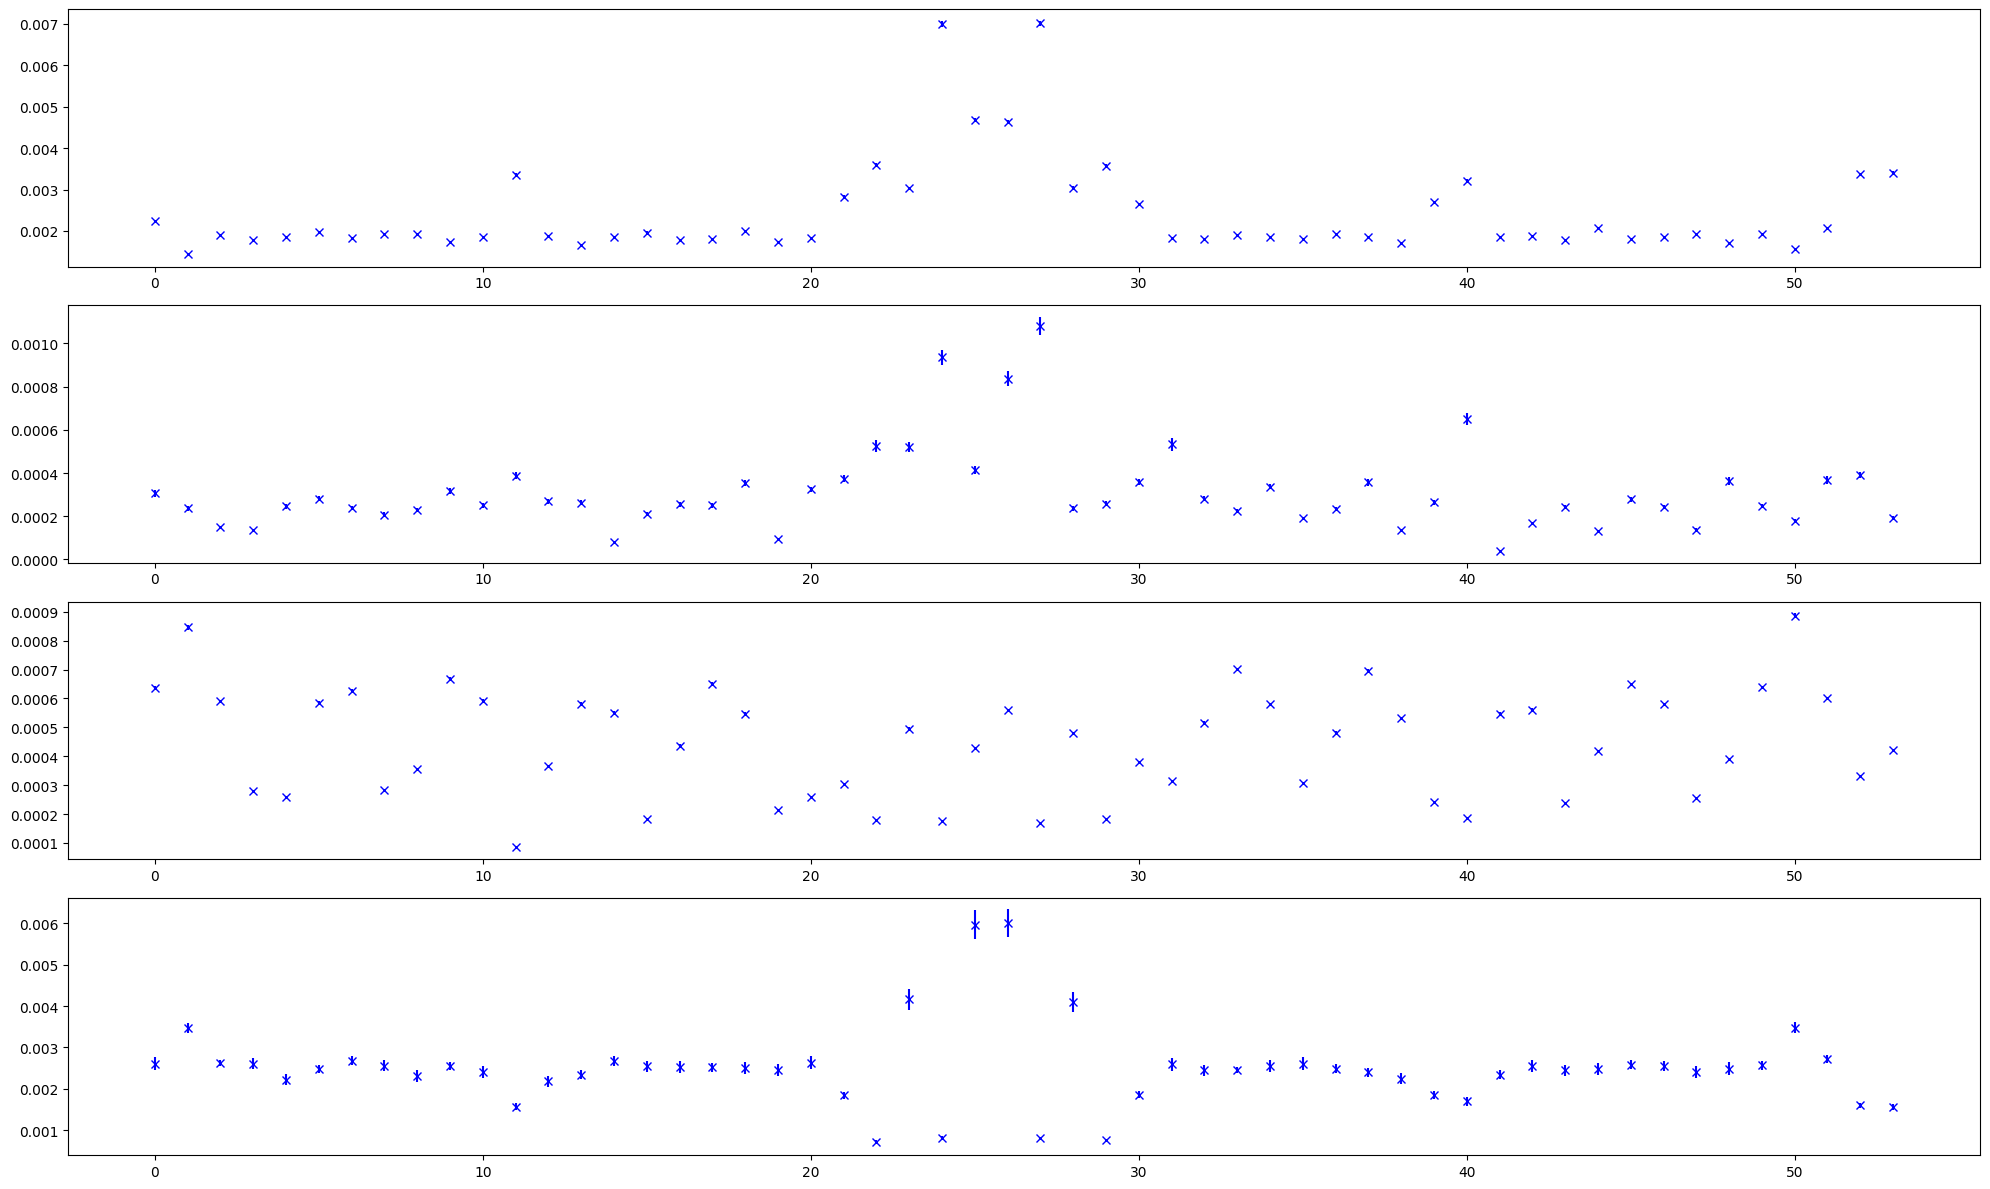

In [10]:
# Plot amplitudes

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), axx.cpu().numpy(), yerr=sigma_axx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), axy.cpu().numpy(), yerr=sigma_axy.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), ayx.cpu().numpy(), yerr=sigma_ayx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), ayy.cpu().numpy(), yerr=sigma_ayy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

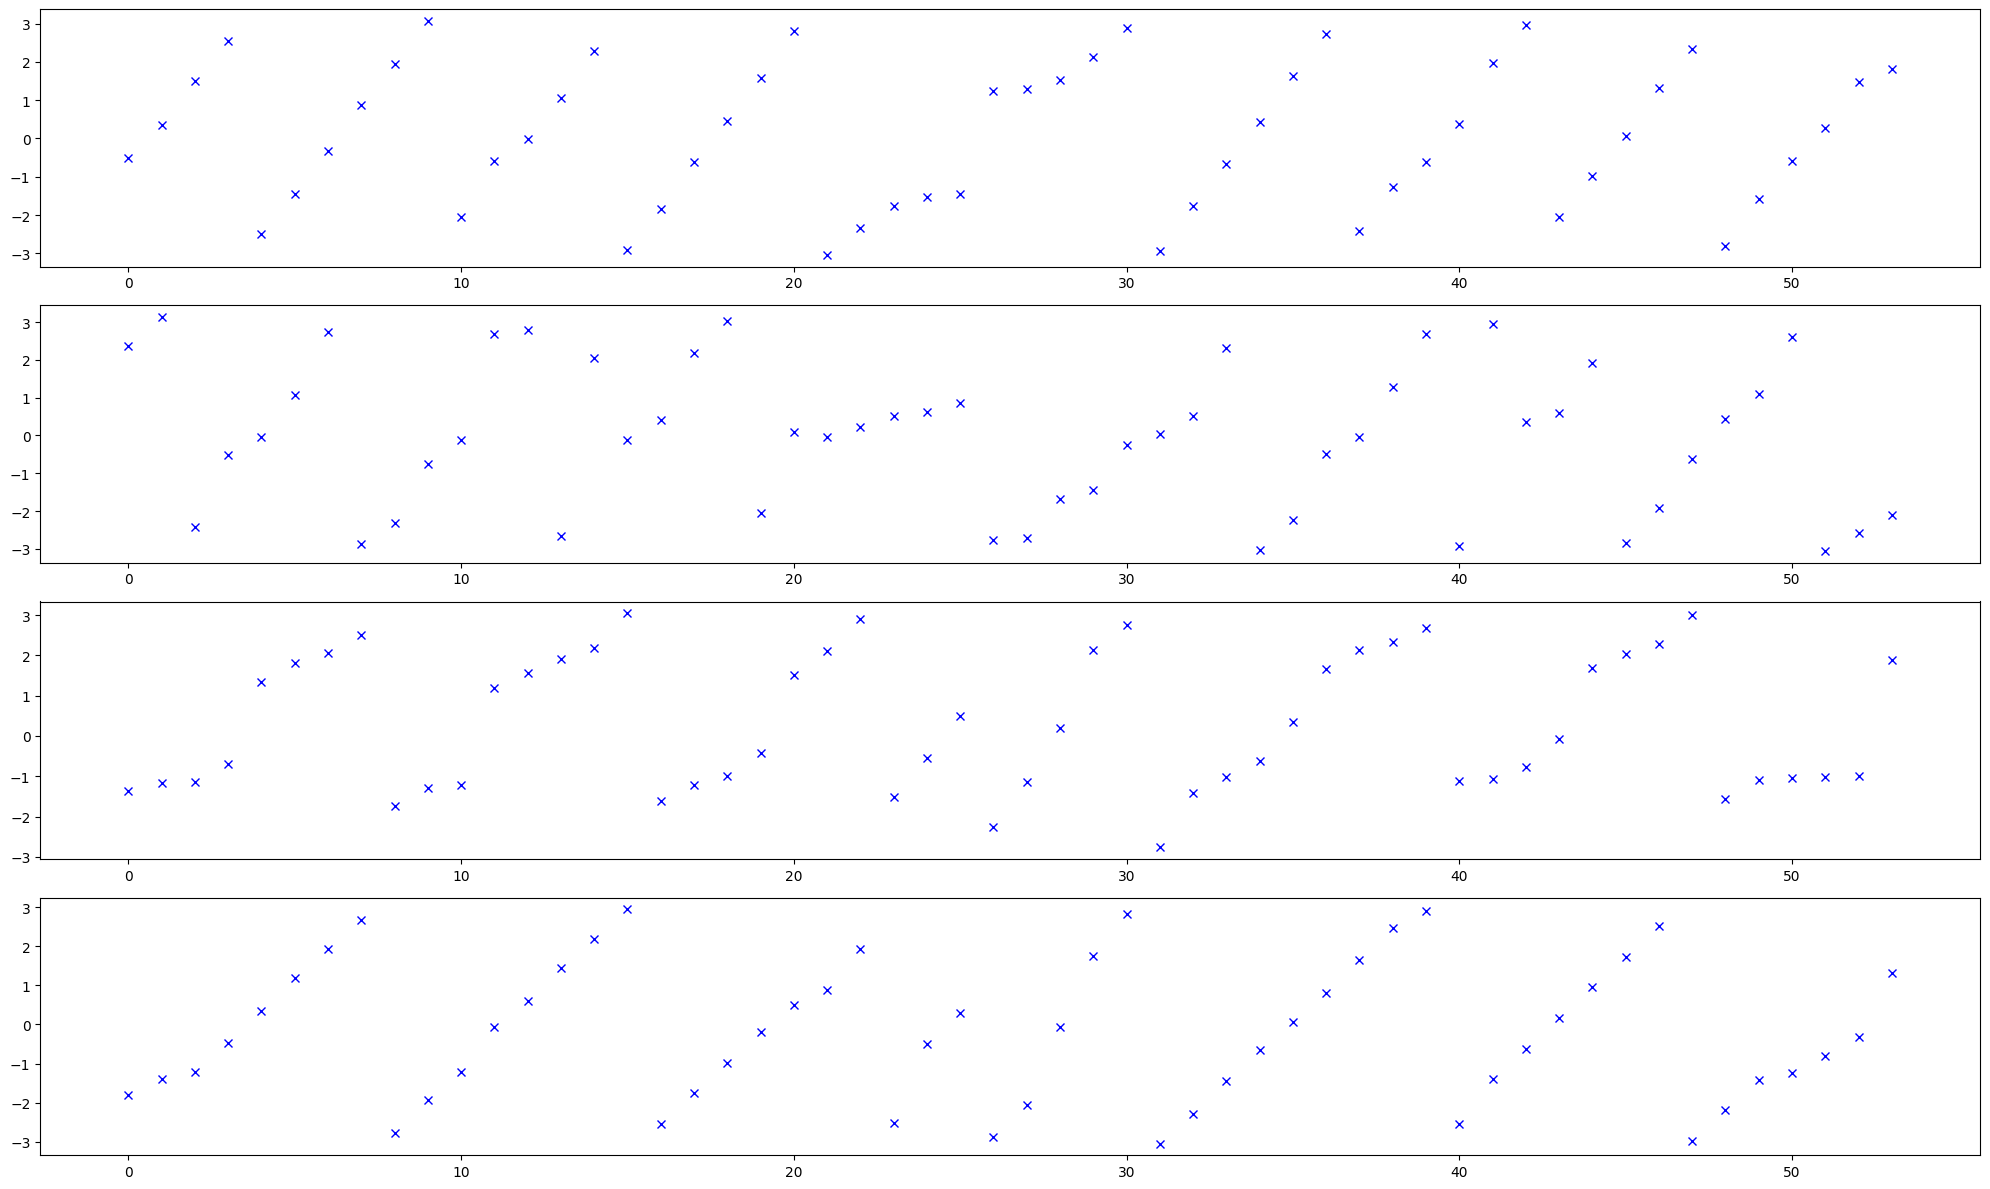

In [11]:
# Plot phases

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), fxx.cpu().numpy(), yerr=sigma_fxx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), fxy.cpu().numpy(), yerr=sigma_fxy.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), fyx.cpu().numpy(), yerr=sigma_fyx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), fyy.cpu().numpy(), yerr=sigma_fyy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

## Twiss from amplitude & phase

In [12]:
# Set twiss

twiss = Twiss(model, table, limit=6)

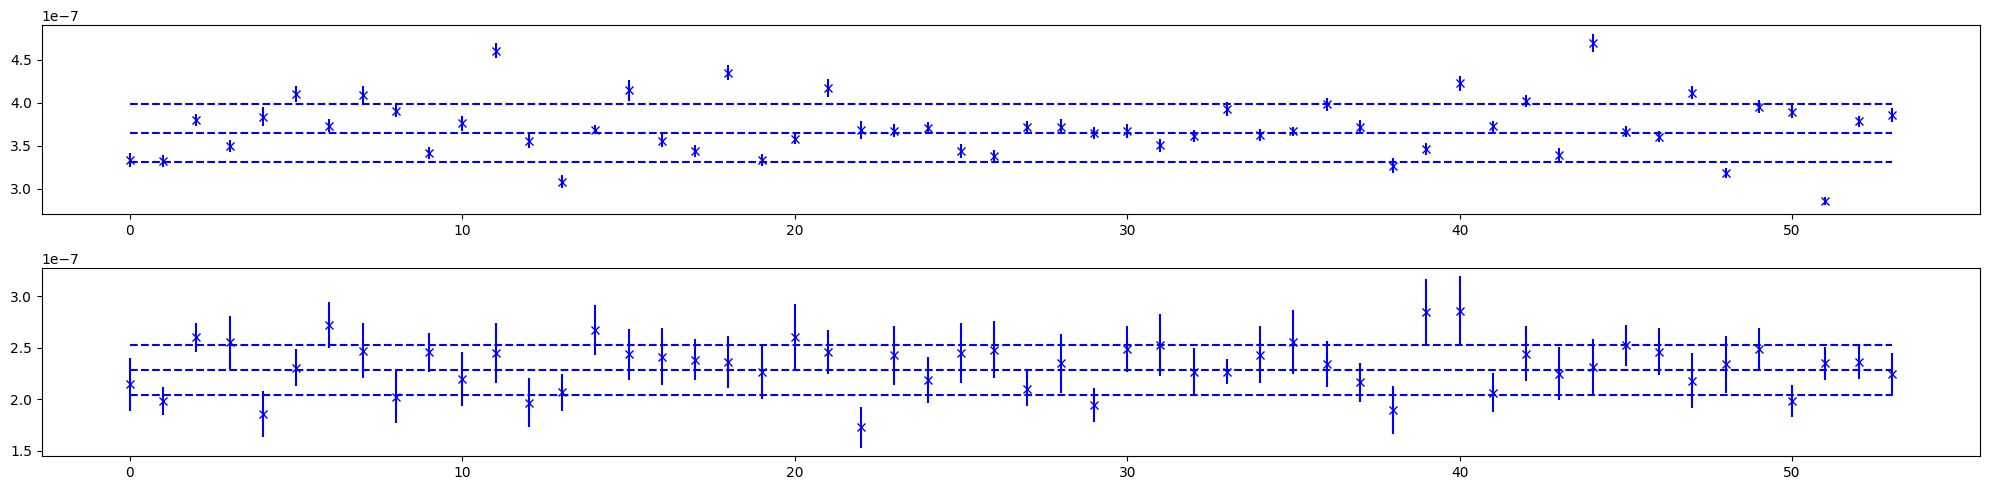

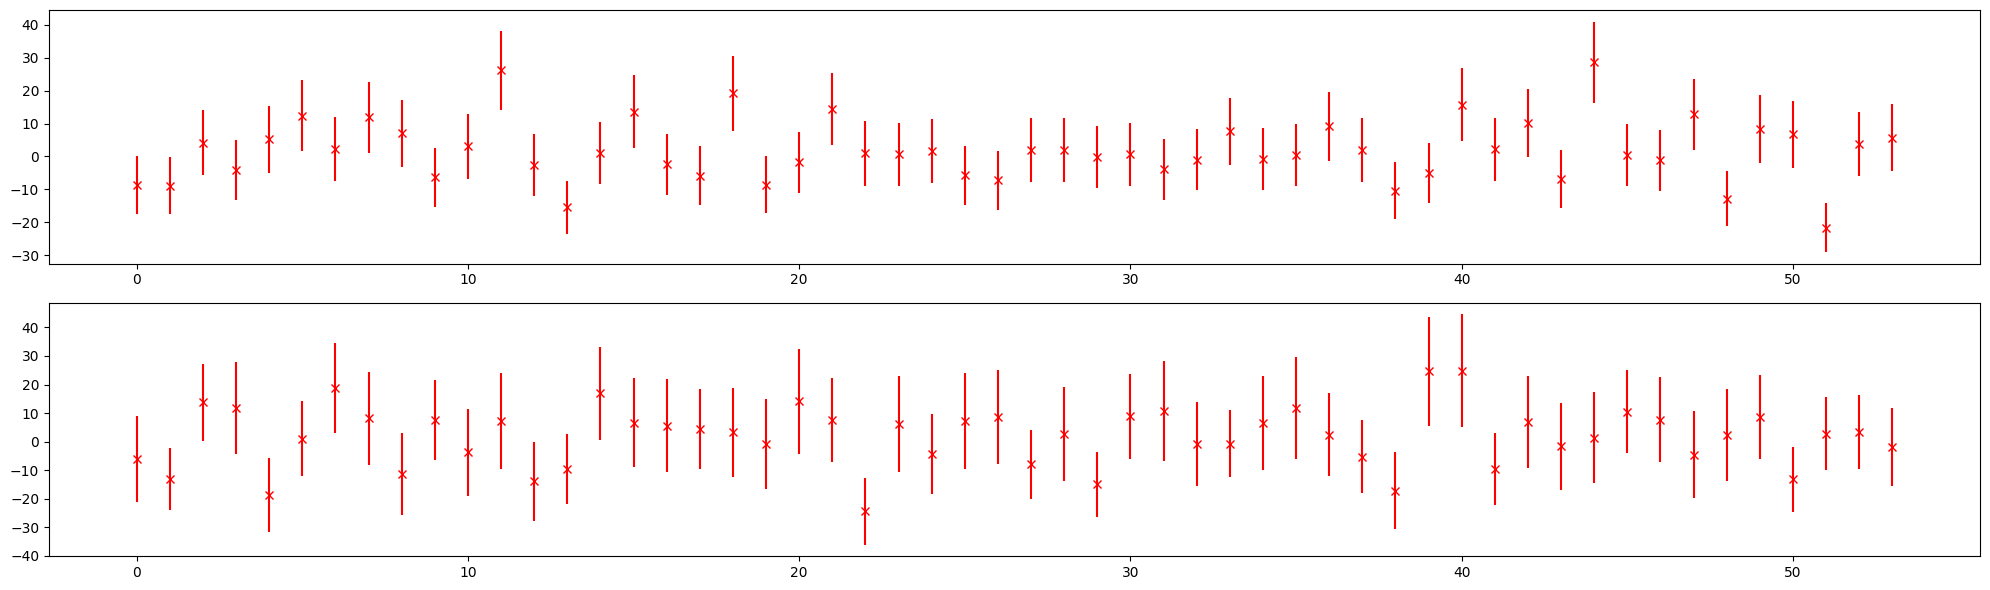

tensor(9.6353, dtype=torch.float64)
tensor(10.6321, dtype=torch.float64)



In [13]:
# Estimate twiss from amplitude (model beta functions are used to estimate invariants)

twiss.get_action()
twiss.get_twiss_from_amplitude()

# Estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

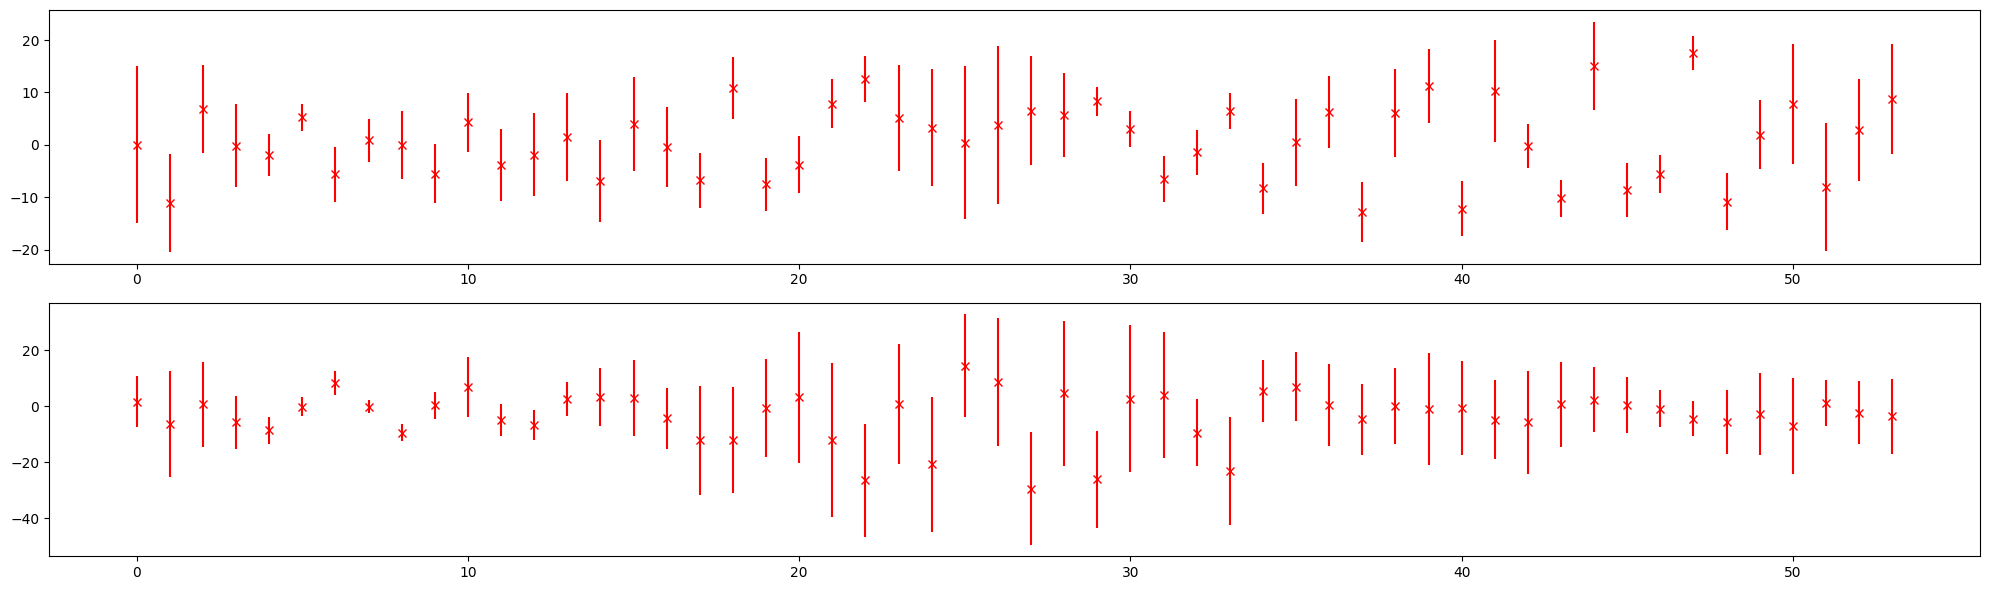

tensor(7.3087, dtype=torch.float64)
tensor(9.4617, dtype=torch.float64)



In [14]:
# Estimate twiss from phase

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 6.0}, model={'use': True, 'threshold': 0.5}, value={'use': True, 'threshold': 0.5}, sigma={'use': True, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 6.0}, model={'use': True, 'threshold': 0.5}, value={'use': True, 'threshold': 0.5}, sigma={'use': True, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

# Estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

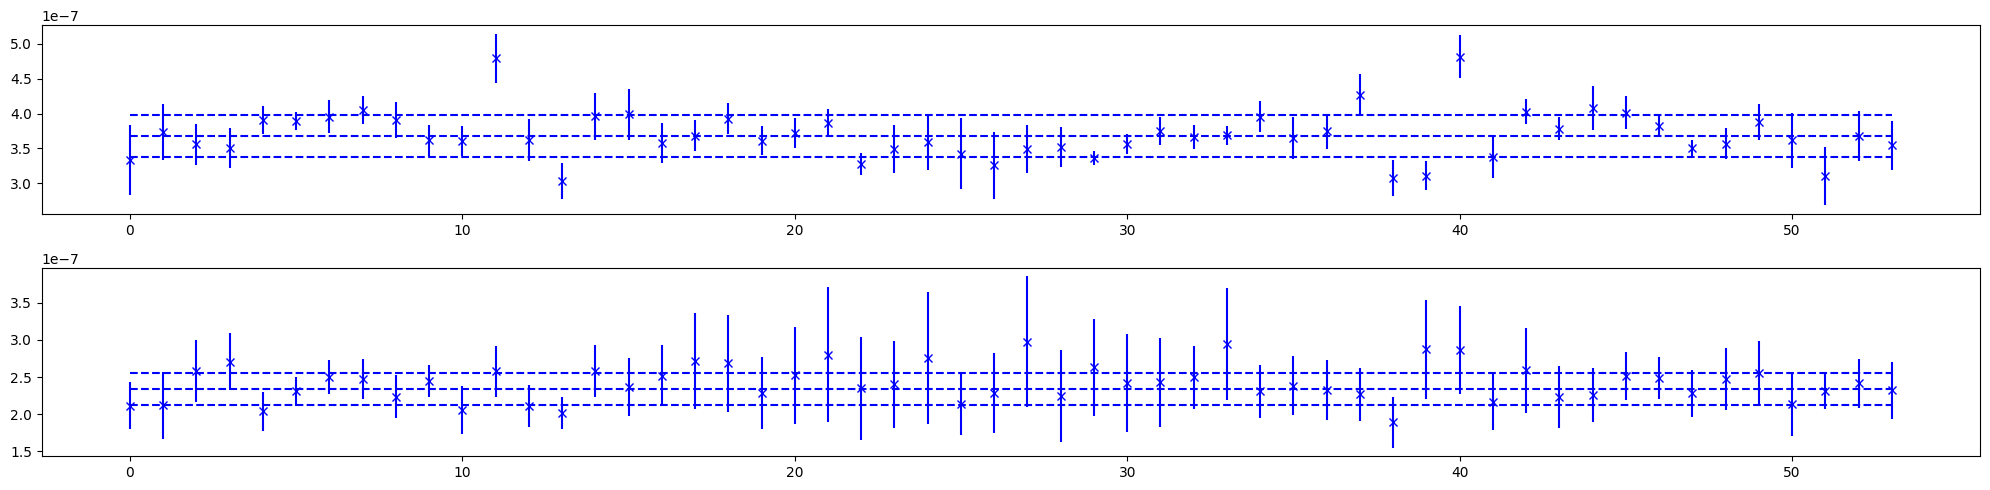

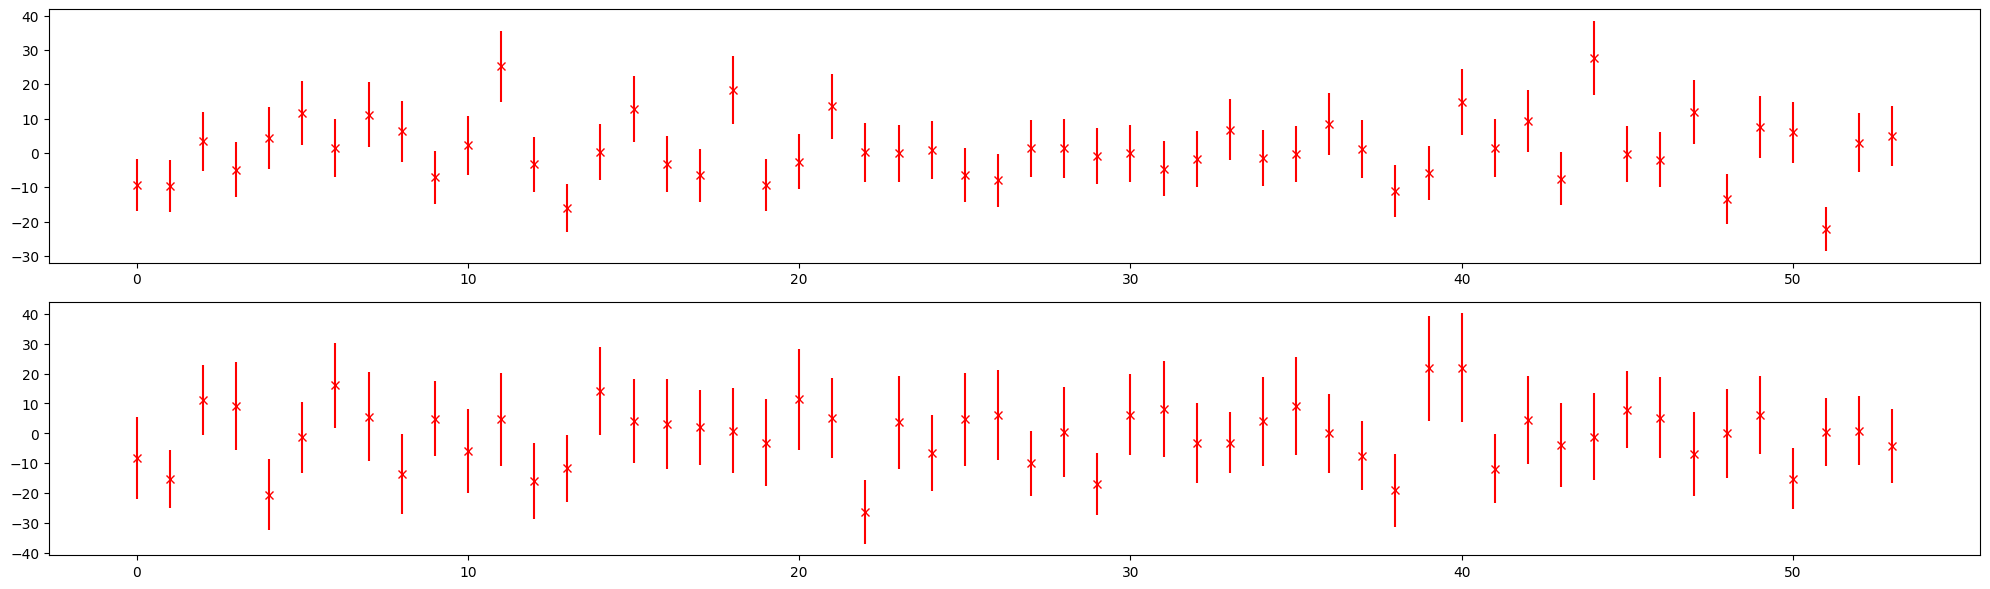

tensor(9.4488, dtype=torch.float64)
tensor(10.2270, dtype=torch.float64)



In [15]:
# Estimate twiss from amplitude (use twiss from phase for action estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

## Calibration scales

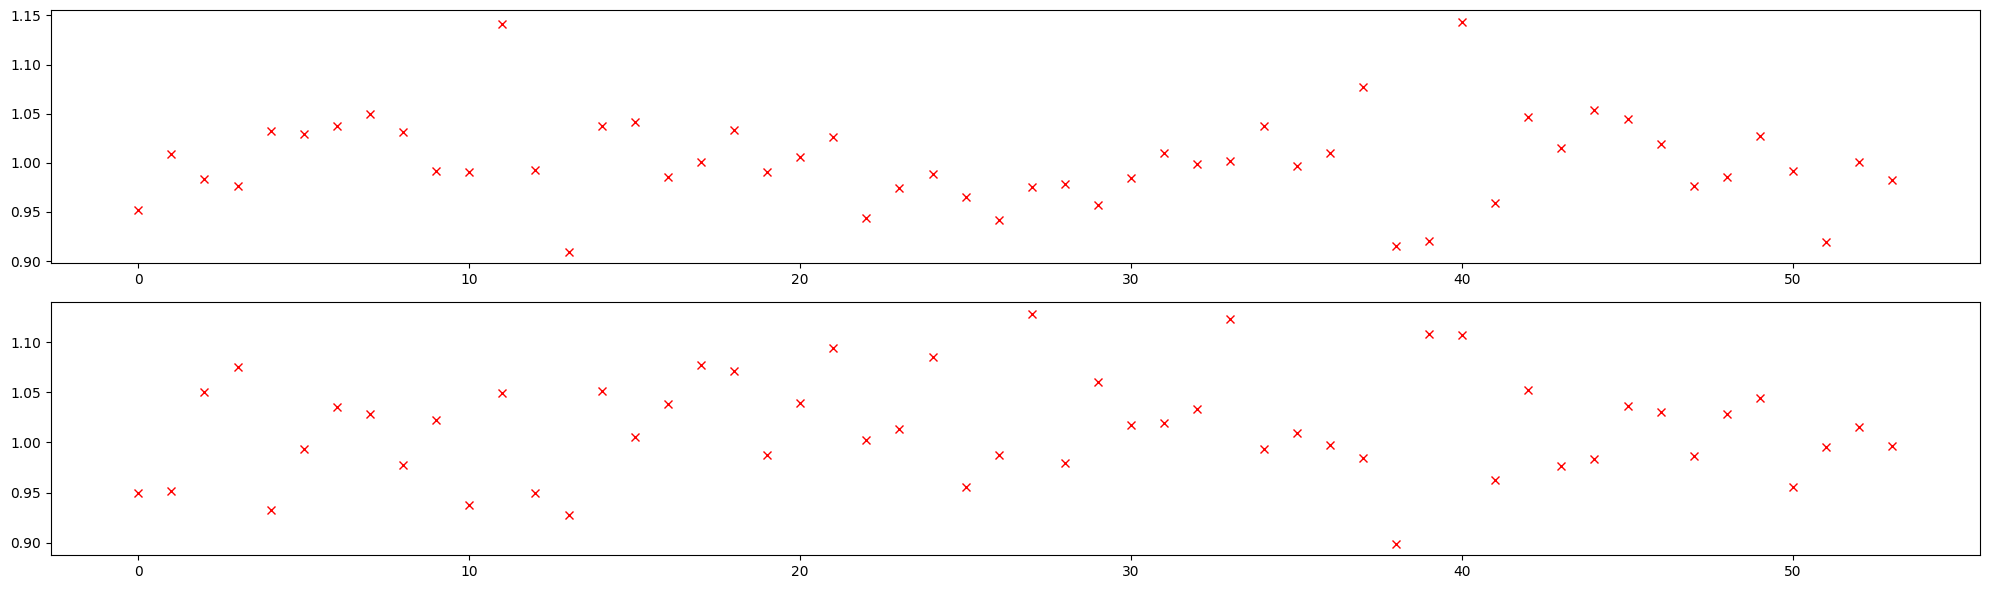

tensor(1.0016, dtype=torch.float64)
tensor(0.0465, dtype=torch.float64)

tensor(1.0150, dtype=torch.float64)
tensor(0.0516, dtype=torch.float64)



In [16]:
# Calibration scales from ratio

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

gxx_phase = (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt()
gyy_phase = (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt()

print(gxx_phase.mean())
print(gxx_phase.std())
print()

print(gyy_phase.mean())
print(gyy_phase.std())
print()

In [17]:
# Note, mean scale calibration errors are close to one

## Invariants

In [18]:
%%time

# Estimate twiss from invariant fit

count = 64

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.80,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 38.4 s, sys: 2.3 s, total: 40.7 s
Wall time: 2min 28s


In [19]:
# Process fitted invariants

ix_out = data[:, 0, 0]
iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix_out, iy_out, sigma_ix, sigma_iy)

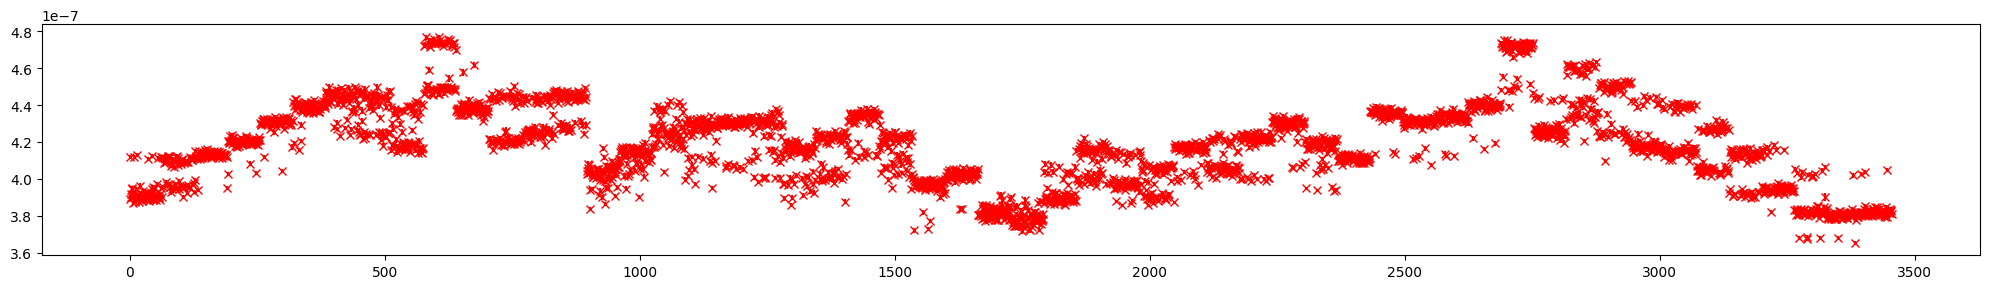

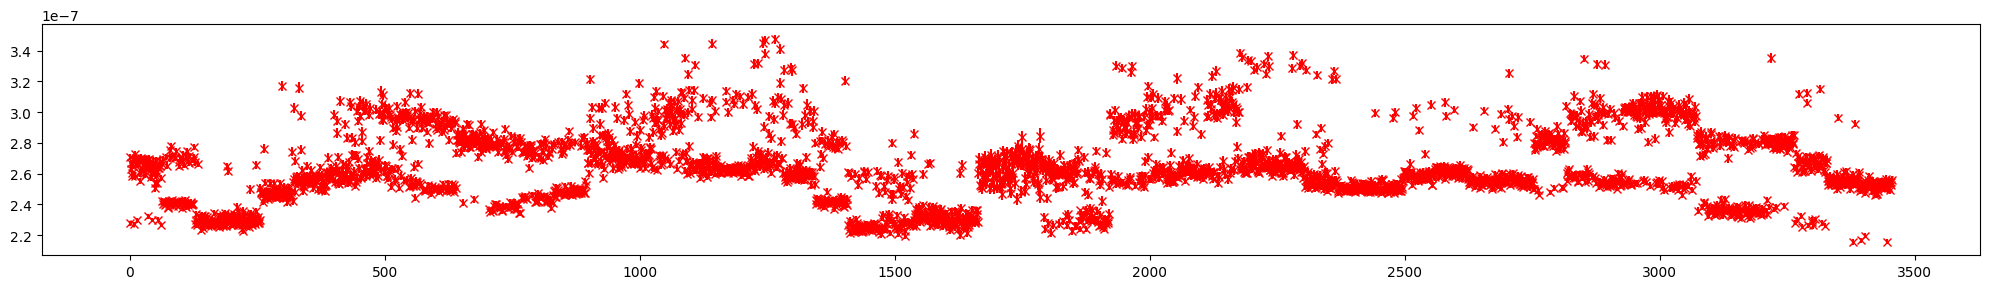

In [20]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.tight_layout()
plt.show()

In [21]:
# Process twiss

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

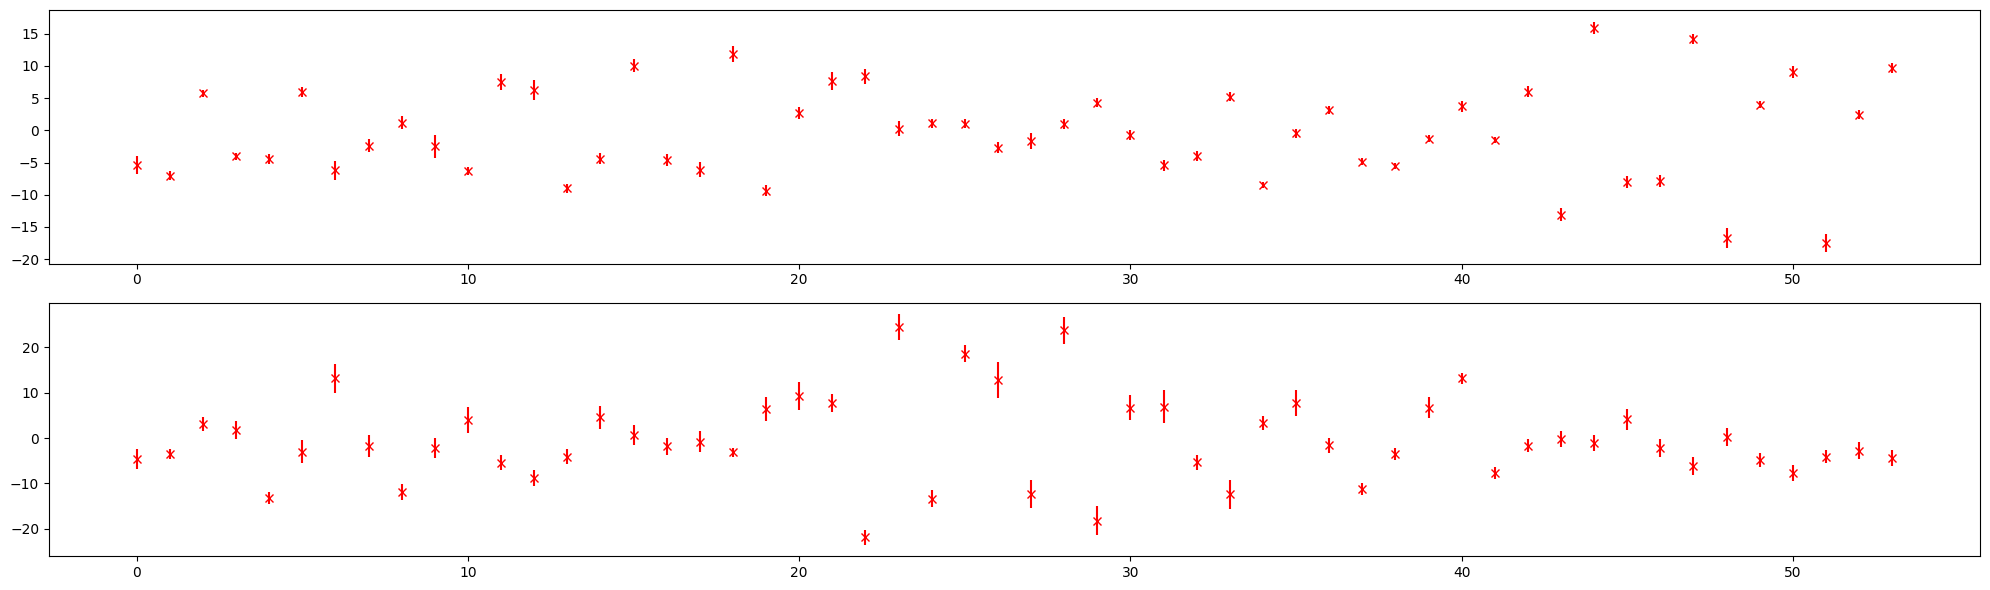

tensor(7.2321, dtype=torch.float64)
tensor(9.3044, dtype=torch.float64)



In [22]:
# Estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

tensor(0.0898, dtype=torch.float64)

tensor(0.2116, dtype=torch.float64)

tensor(0.0347, dtype=torch.float64)

tensor(0.0582, dtype=torch.float64)

tensor(0.4156, dtype=torch.float64)

tensor(0.4832, dtype=torch.float64)

tensor(0.3628, dtype=torch.float64)

tensor(0.0938, dtype=torch.float64)



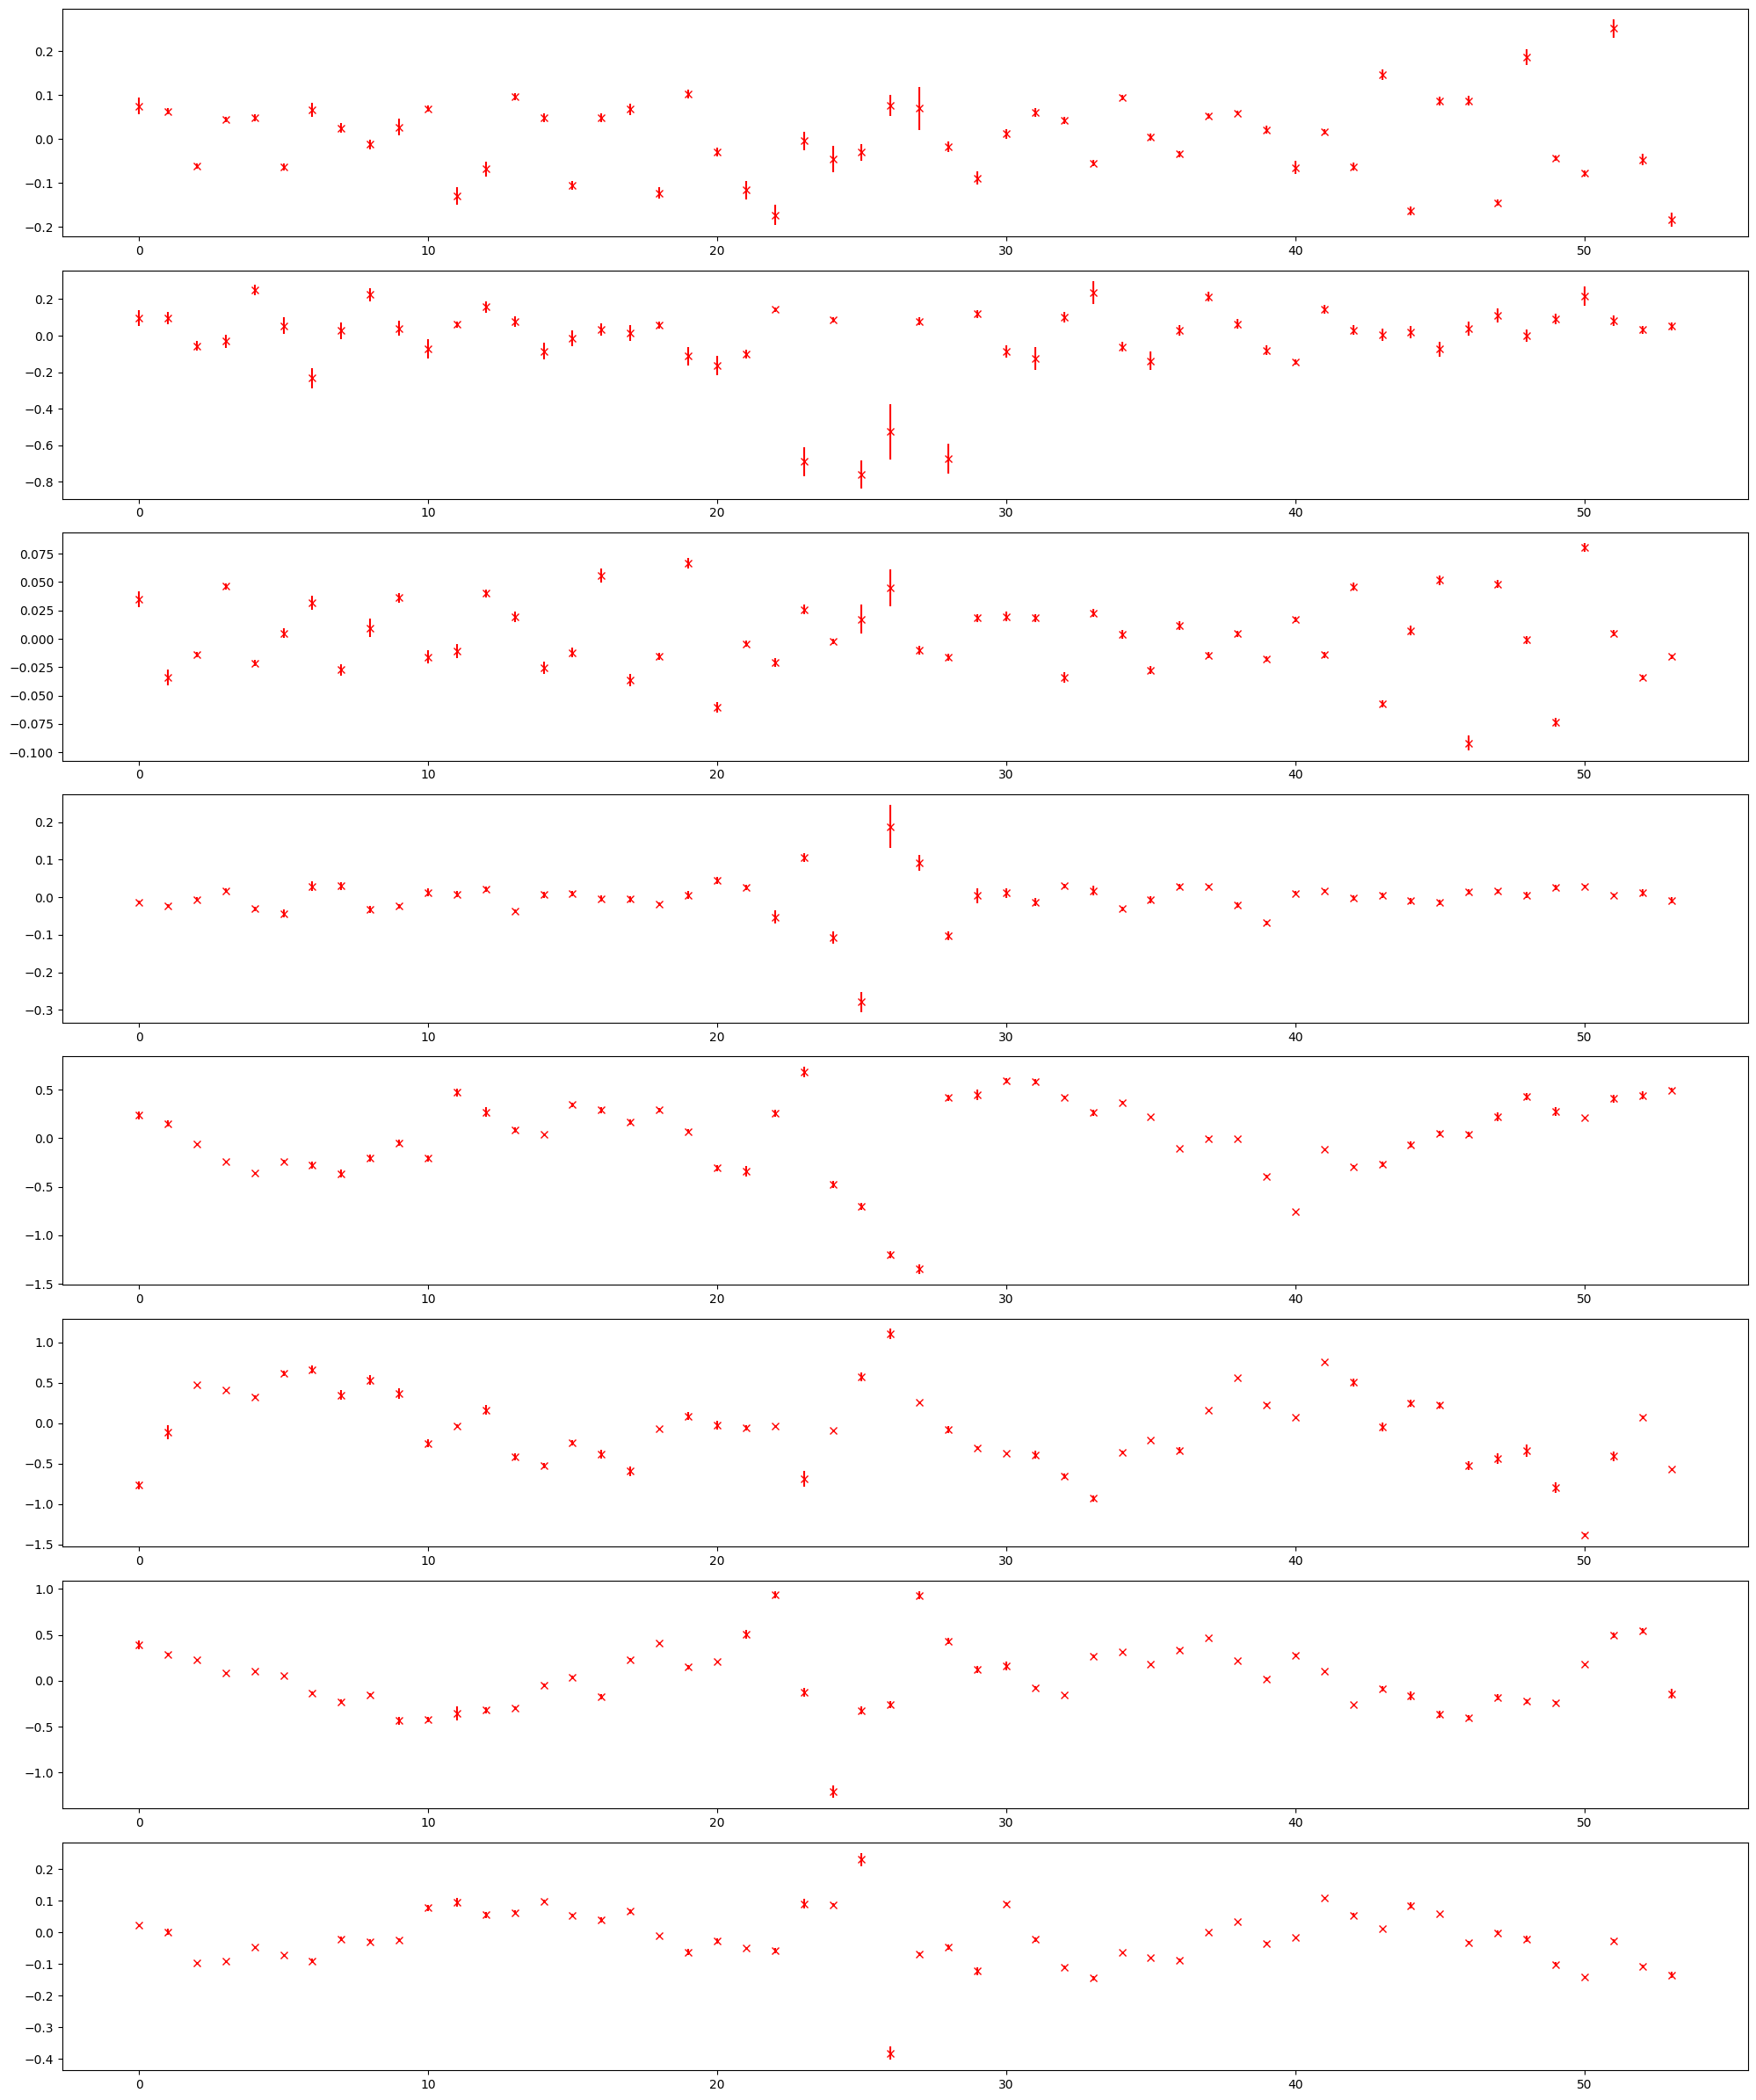

In [23]:
# Estimated twiss

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

In [24]:
# Rescale TbT using estimated gxx and gyy from ratio

twiss.table.x = X.data/gxx_phase.reshape(-1, 1)
twiss.table.y = Y.data/gyy_phase.reshape(-1, 1)

In [25]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 256

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 128,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.80,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 2min 8s, sys: 6.26 s, total: 2min 14s
Wall time: 5min 29s


In [26]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

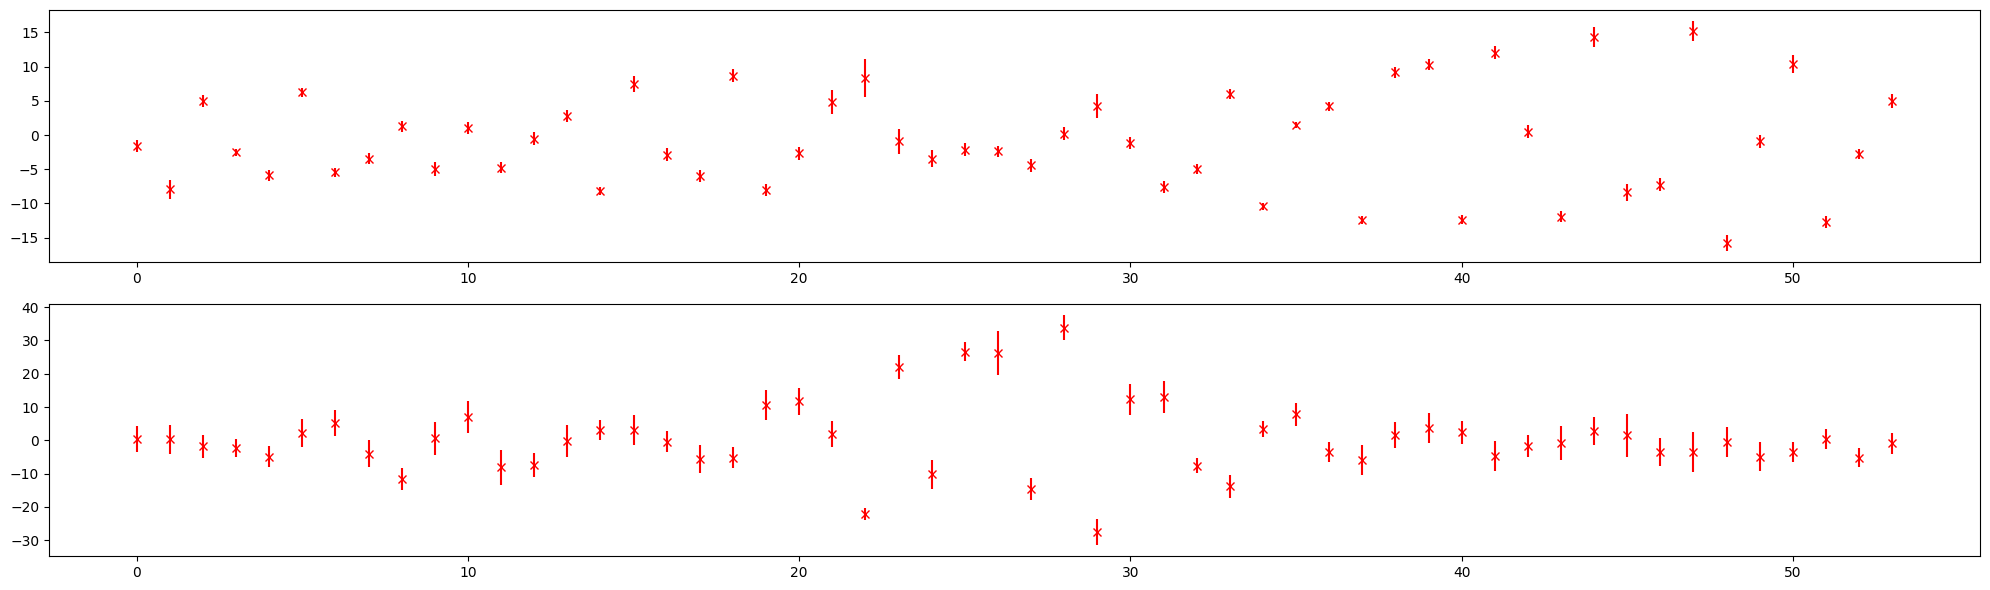

tensor(7.3042, dtype=torch.float64)
tensor(10.6609, dtype=torch.float64)



In [27]:
# Estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

tensor(0.0949, dtype=torch.float64)

tensor(0.2733, dtype=torch.float64)

tensor(0.0353, dtype=torch.float64)

tensor(0.0883, dtype=torch.float64)

tensor(0.4208, dtype=torch.float64)

tensor(0.4758, dtype=torch.float64)

tensor(0.3577, dtype=torch.float64)

tensor(0.0903, dtype=torch.float64)



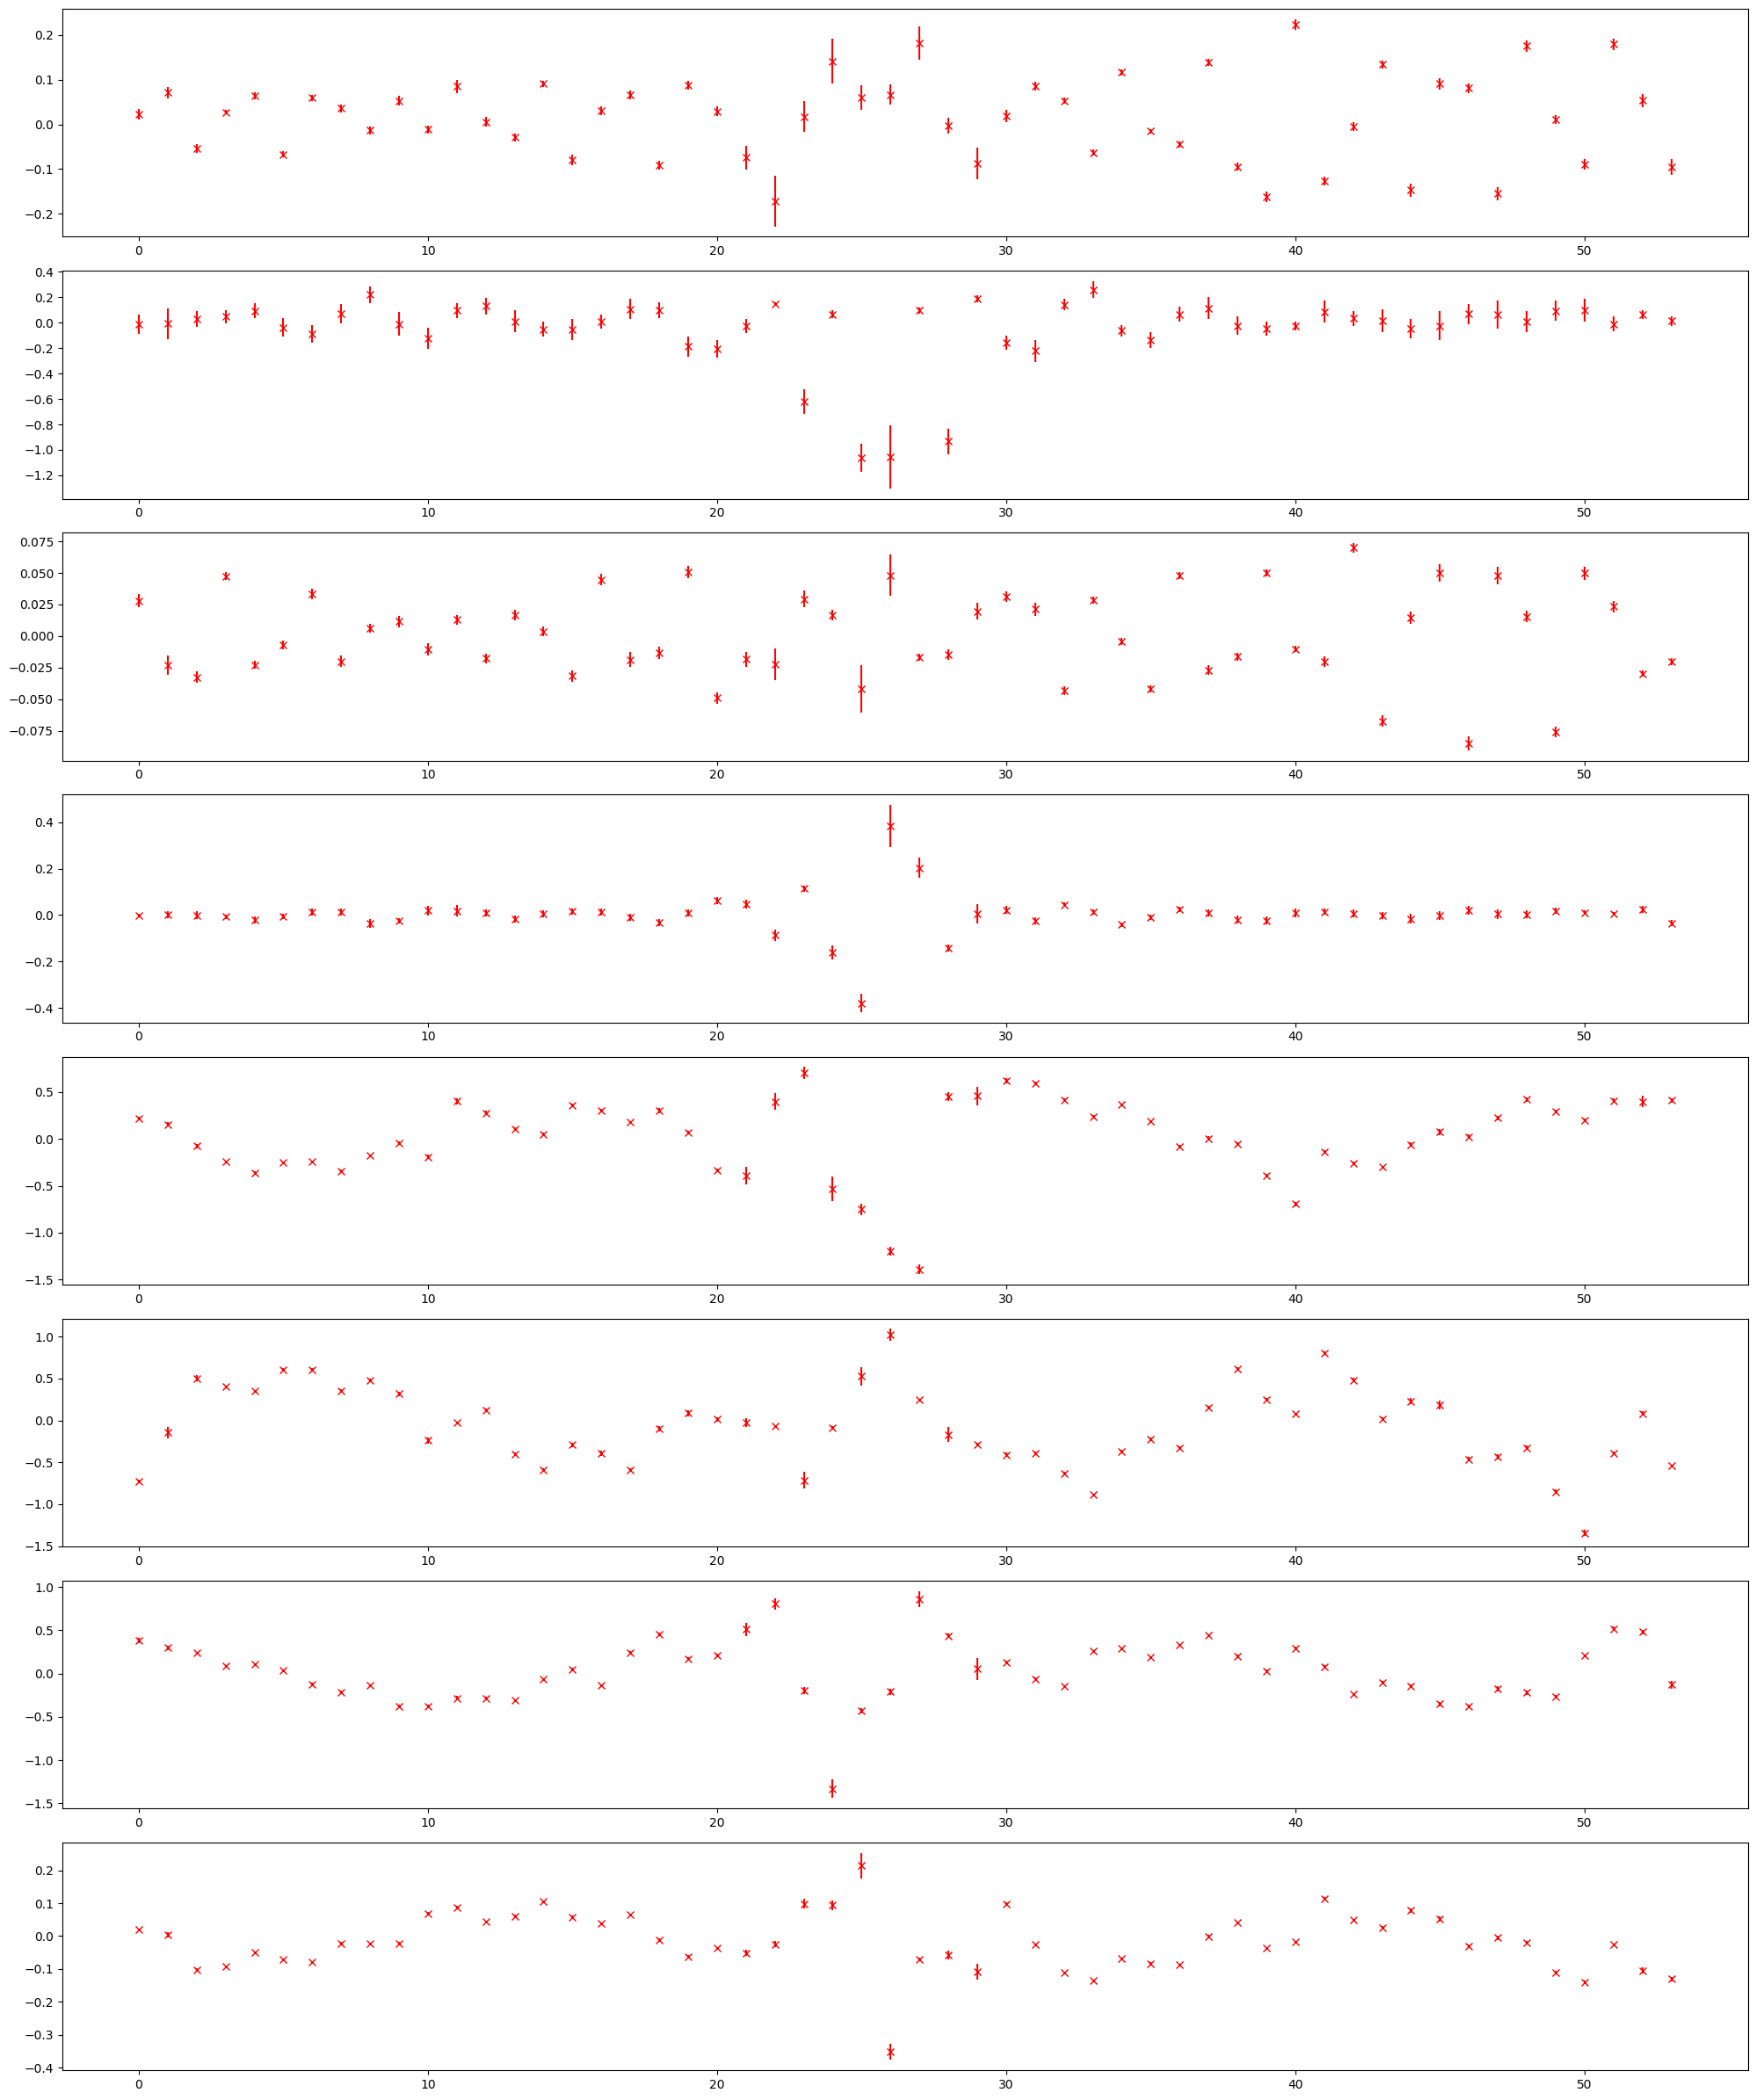

In [28]:
# Estimated twiss

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

In [29]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

In [30]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([54, 4, 256])


In [31]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

ix_out = []
iy_out = []

for location in range(model.monitor_count):
    
    ix_out_monitor = []
    iy_out_monitor = []
    
    for _ in range(256):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        ix_out_monitor.append(IX)
        iy_out_monitor.append(IY)
        
    ix_out.append(ix_out_monitor)
    iy_out.append(iy_out_monitor)

ix_out = torch.stack([torch.stack(IX) for IX in ix_out]).reshape(model.monitor_count, -1)
iy_out = torch.stack([torch.stack(IY) for IY in iy_out]).reshape(model.monitor_count, -1)

## Calibration scales (invariant)

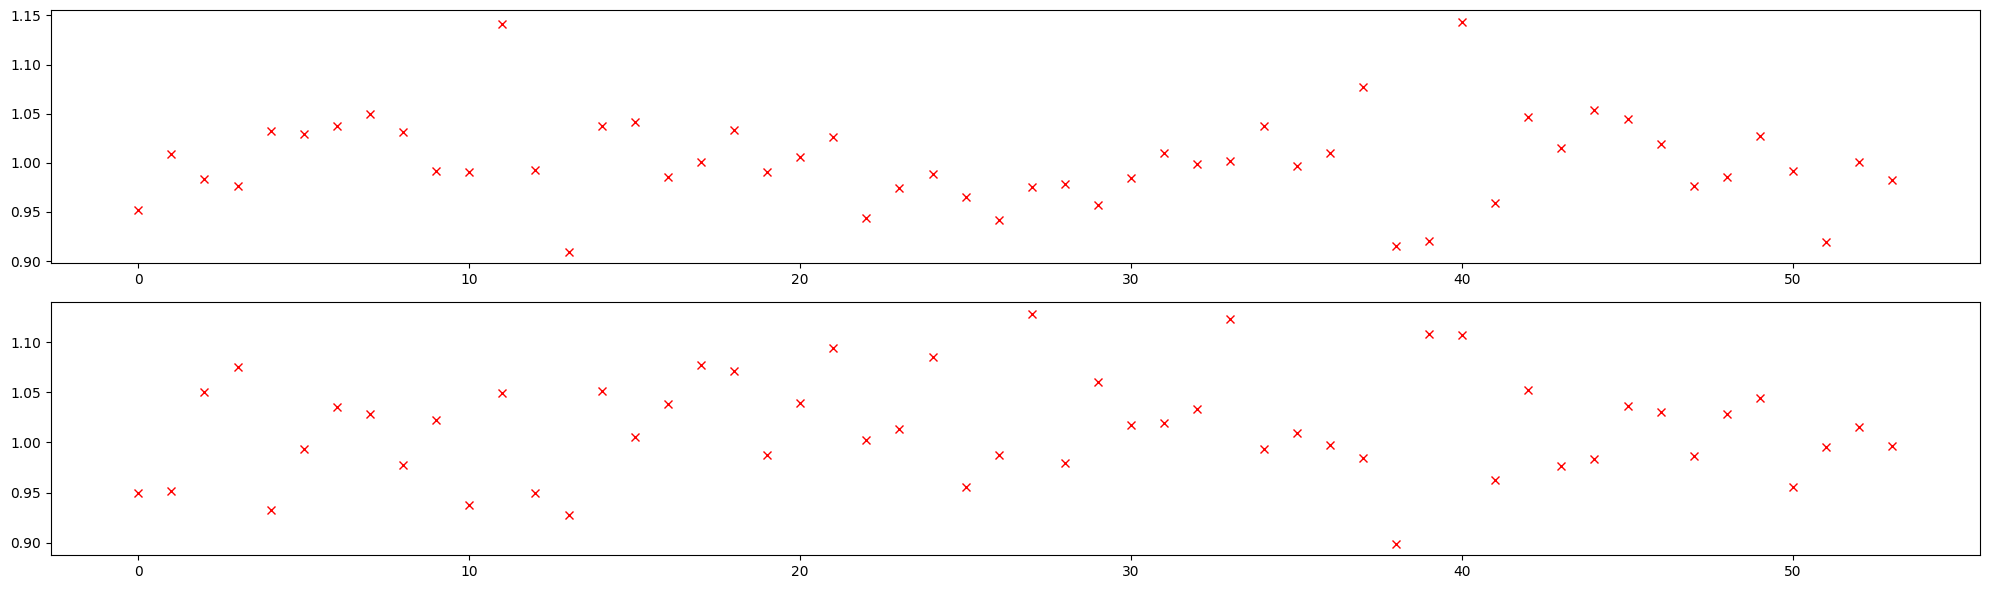

tensor(1.0016, dtype=torch.float64)
tensor(0.0465, dtype=torch.float64)

tensor(1.0150, dtype=torch.float64)
tensor(0.0516, dtype=torch.float64)



In [32]:
# Ratio (invariants from phase twiss)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

gxx_phase = (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt()
gyy_phase = (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt()

print(gxx_phase.mean())
print(gxx_phase.std())
print()

print(gyy_phase.mean())
print(gyy_phase.std())
print()

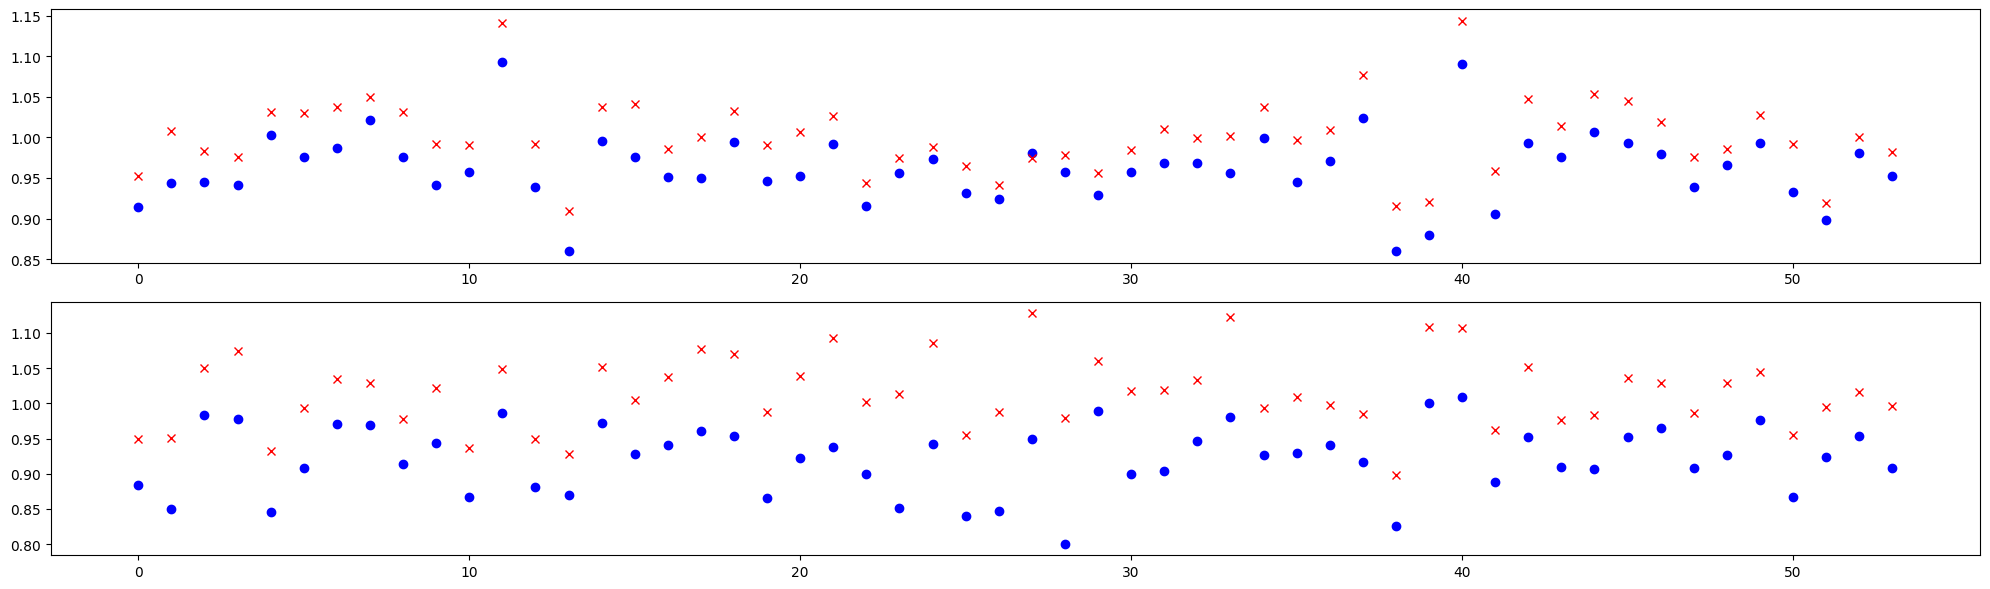

tensor(0.9623, dtype=torch.float64)
tensor(0.0438, dtype=torch.float64)

tensor(0.9218, dtype=torch.float64)
tensor(0.0484, dtype=torch.float64)



In [33]:
# Ratio (fitted invariants & twiss from scaled TbT)

twiss.get_action(jx=ix_out.mean(-1), jy=iy_out.mean(-1), sigma_jx=ix_out.mean(-1), sigma_jy=iy_out.mean(-1))
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/value_bx).sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/value_by).sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

gxx_fit = (twiss.data_amplitude['bx']/value_bx).sqrt()
gyy_fit = (twiss.data_amplitude['by']/value_by).sqrt()

print(gxx_fit.mean())
print(gxx_fit.std())
print()

print(gyy_fit.mean())
print(gyy_fit.std())
print()

## Twiss (BPM)

In [34]:
# Set  estimated invariants

ix_fit = ix_out.mean()
iy_fit = iy_out.mean()


print(ix_fit)
print(iy_fit)
print()

tensor(4.0660e-07, dtype=torch.float64)
tensor(2.8093e-07, dtype=torch.float64)



In [35]:
# n11 (bpm)

n11_estimate = axx/(2*ix_fit).sqrt()

print(root_mean_square(n11 - n11_estimate))
print()

tensor(0.1872, dtype=torch.float64)



In [36]:
# n33 (bpm)

n33_estimate = ayy/(2*iy_fit).sqrt()

print(root_mean_square(n33 - n33_estimate))
print()

tensor(0.3777, dtype=torch.float64)



In [37]:
# n13 (bpm)

n13_estimate = axy/ayy*(fxy - fyy).cos()*(ayy/(2*iy_fit).sqrt())

print(root_mean_square(n13 - n13_estimate))
print()

tensor(0.3754, dtype=torch.float64)



In [38]:
# n14 (bpm)

n14_estimate = axy/ayy*(fxy - fyy).sin()*(ayy/(2*iy_fit).sqrt())

print(root_mean_square(n14 - n14_estimate))
print()

tensor(0.3143, dtype=torch.float64)



In [39]:
# n31 (bpm)

n31_estimate = ayx/axx*(fyx - fxx).cos()*(axx/(2*ix_fit).sqrt())

print(root_mean_square(n31 - n31_estimate))
print()

tensor(0.3835, dtype=torch.float64)



In [40]:
# n32 (bpm)

n32_estimate = ayx/axx*(fyx- fxx).sin()*(axx/(2*ix_fit).sqrt())

print(root_mean_square(n32 - n32_estimate))
print()

tensor(0.3730, dtype=torch.float64)



## Twiss (BEAM)

In [41]:
# Rescale TbT

twiss.table.x = X.data/gxx_fit.reshape(-1, 1)
twiss.table.y = Y.data/gyy_fit.reshape(-1, 1)

In [42]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 64

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.80,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 37.3 s, sys: 1.74 s, total: 39.1 s
Wall time: 2min 53s


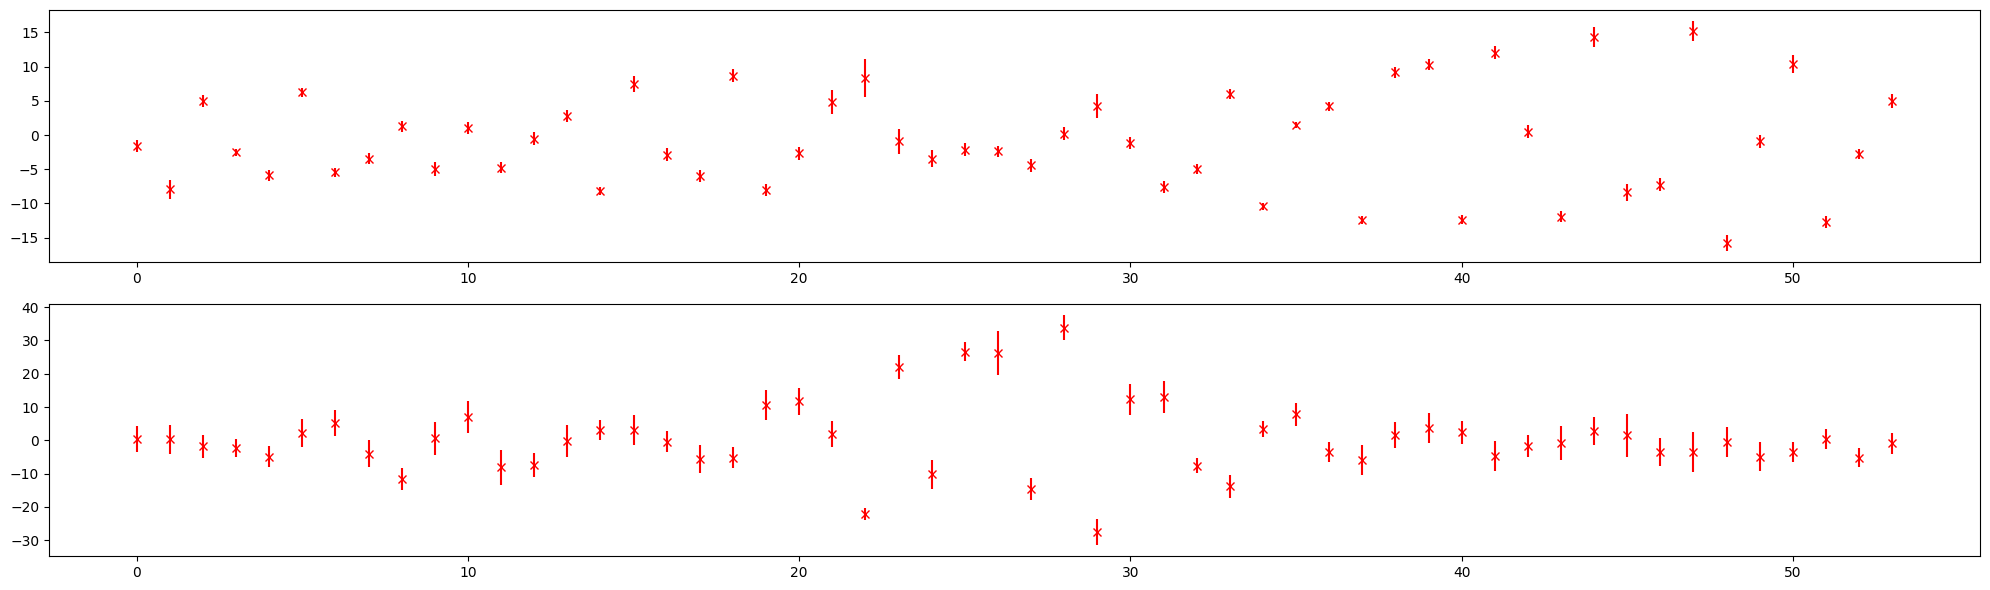

tensor(7.3042, dtype=torch.float64)
tensor(10.6609, dtype=torch.float64)



In [43]:
# Estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

tensor(0.0949, dtype=torch.float64)

tensor(0.2733, dtype=torch.float64)

tensor(0.0353, dtype=torch.float64)

tensor(0.0883, dtype=torch.float64)

tensor(0.4208, dtype=torch.float64)

tensor(0.4758, dtype=torch.float64)

tensor(0.3577, dtype=torch.float64)

tensor(0.0903, dtype=torch.float64)



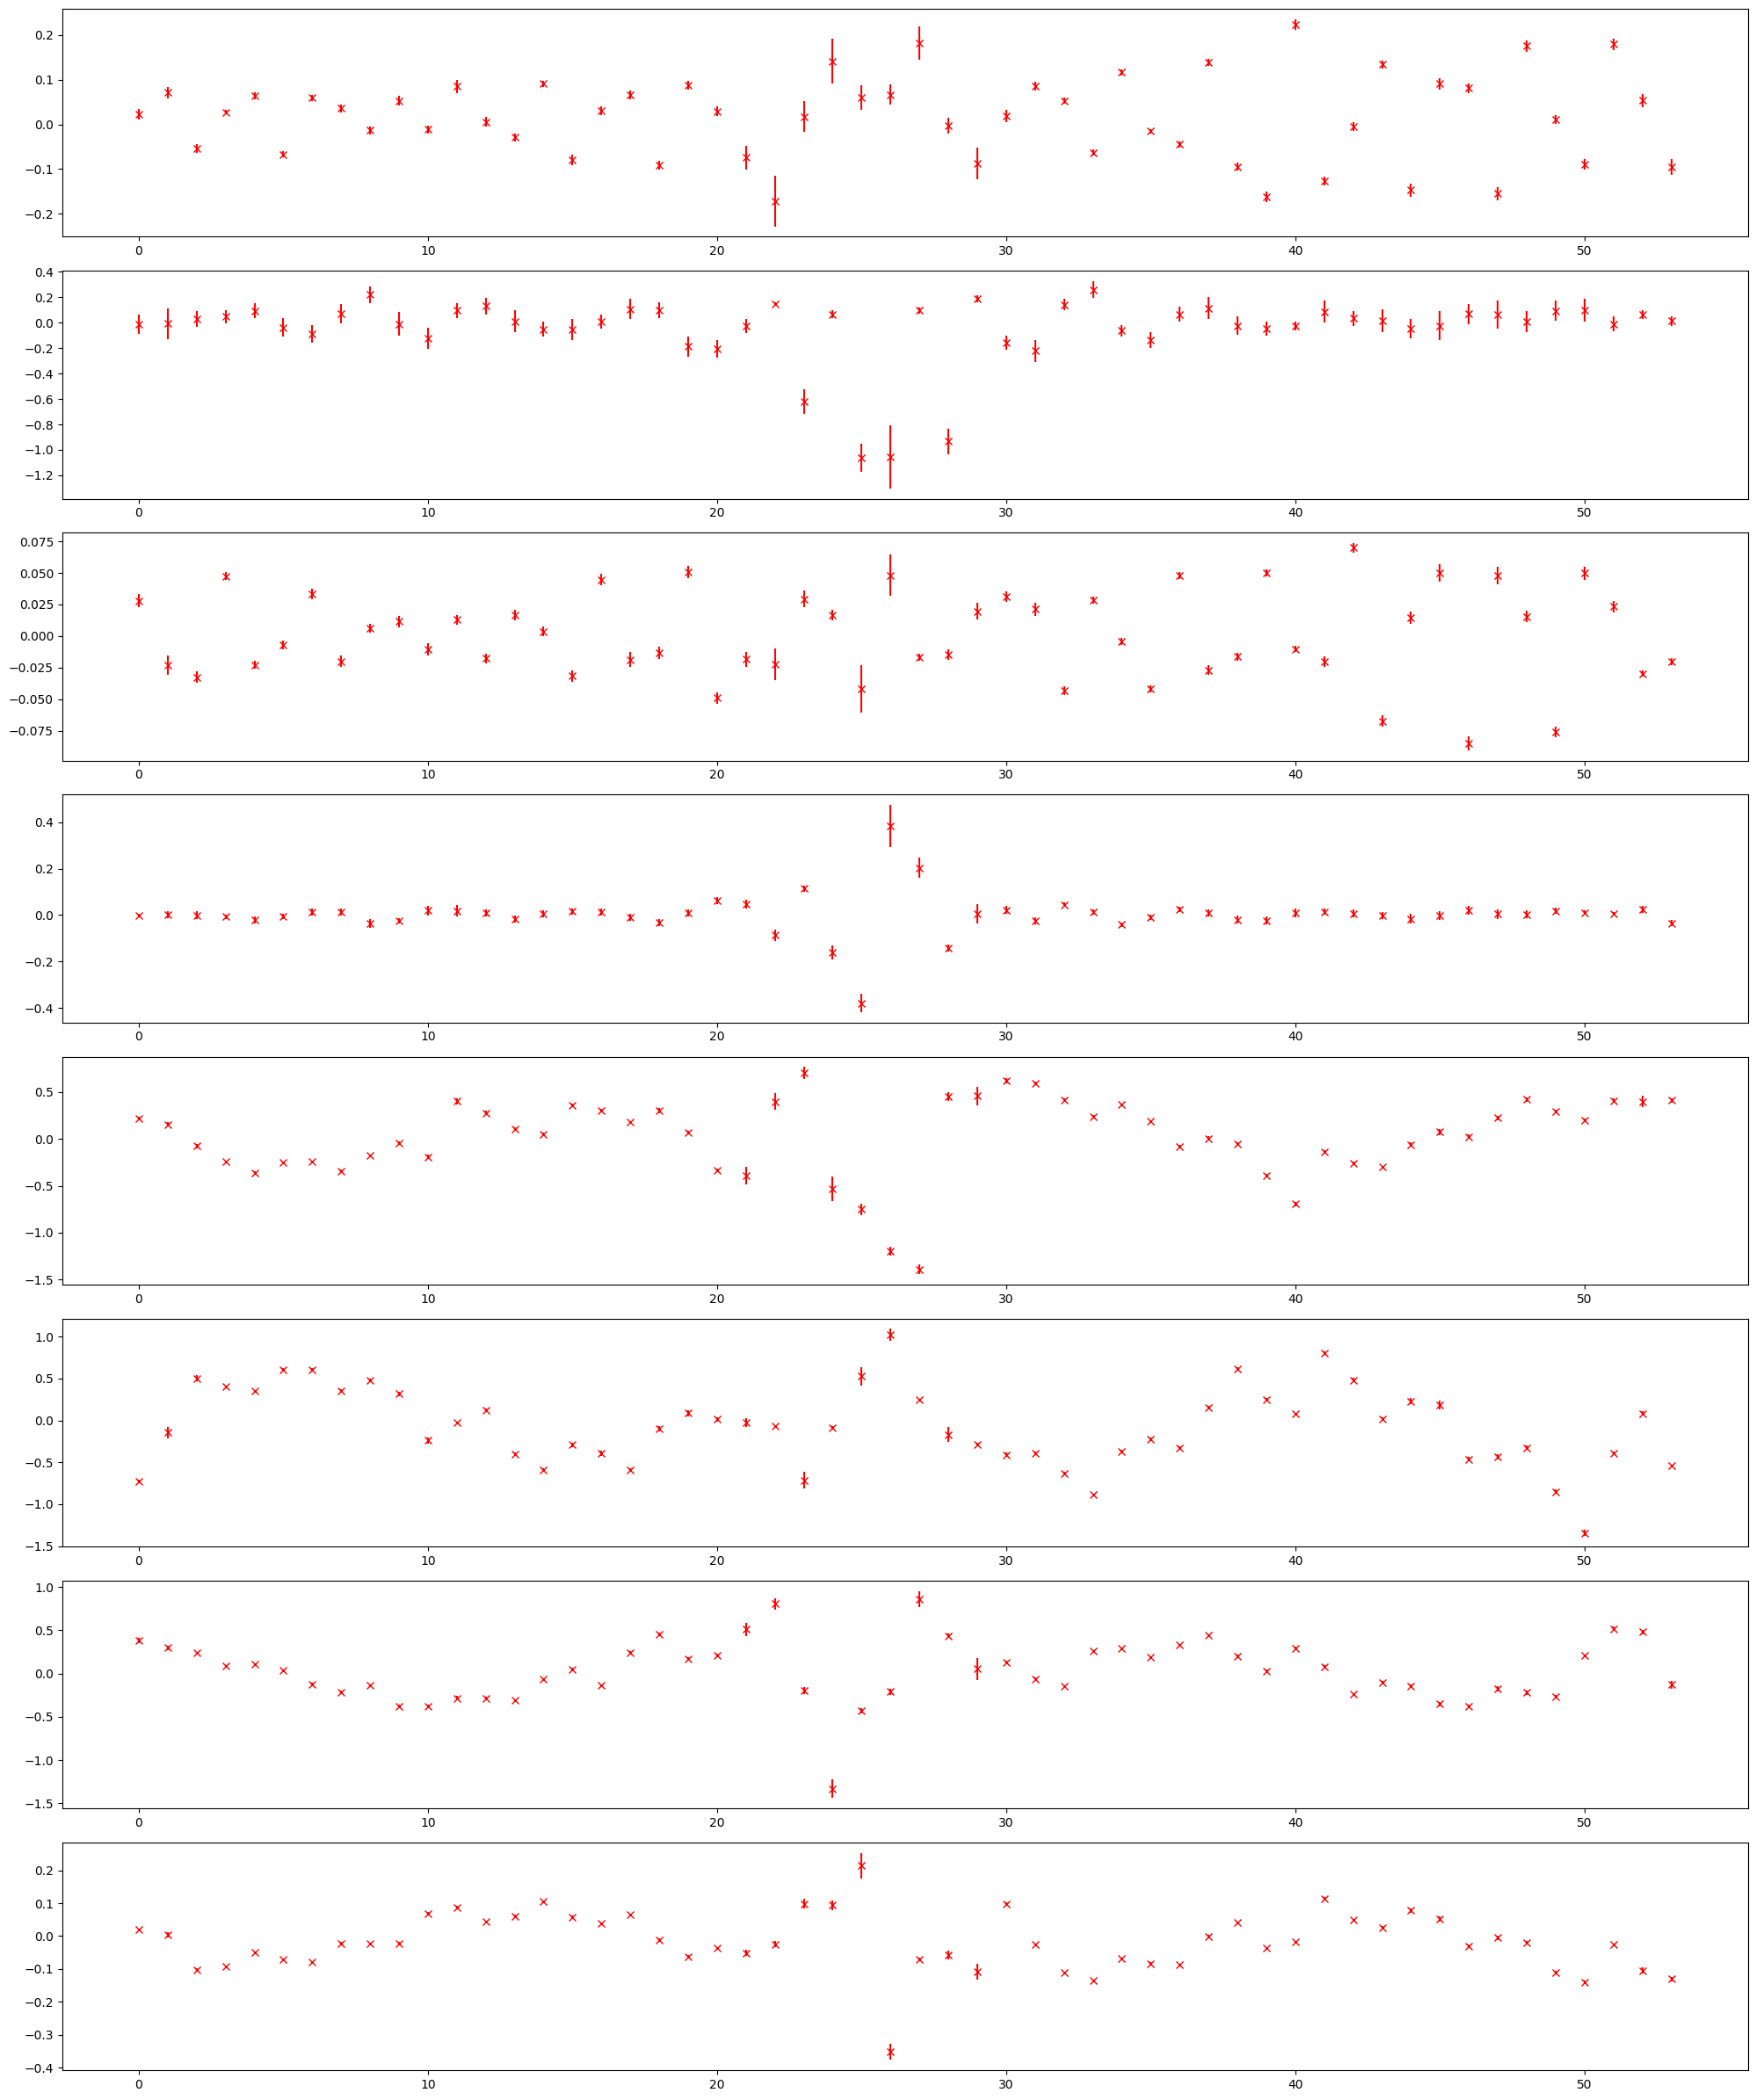

In [44]:
# Estimated twiss

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

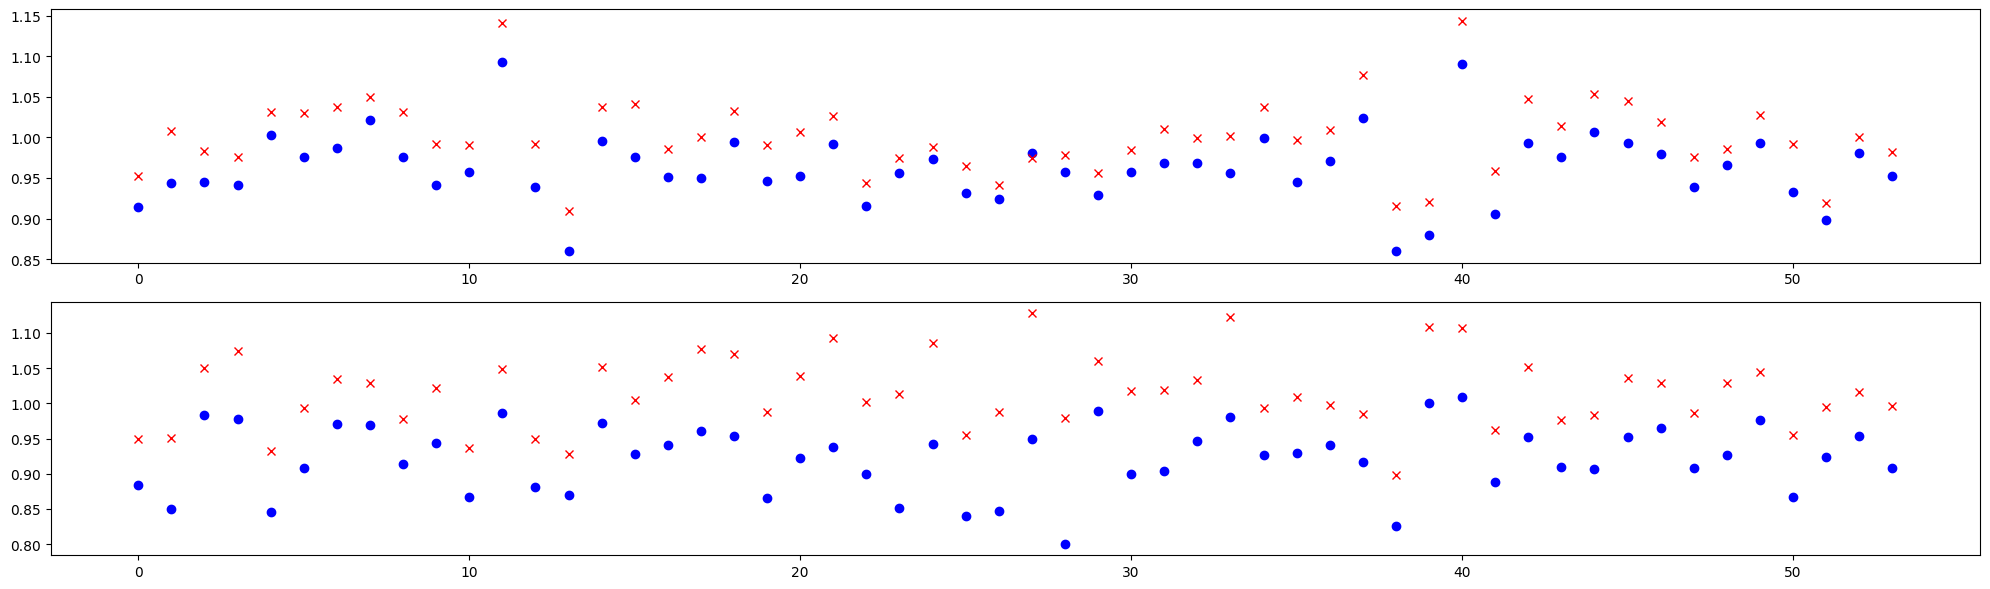

tensor(0.9623, dtype=torch.float64)
tensor(0.0438, dtype=torch.float64)

tensor(0.9218, dtype=torch.float64)
tensor(0.0484, dtype=torch.float64)



In [45]:
# Update calibraton scales using estimated twiss parameters

twiss.get_action(jx=ix_out.mean(-1), jy=iy_out.mean(-1), sigma_jx=ix_out.mean(-1), sigma_jy=iy_out.mean(-1))
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/value_bx).sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/value_by).sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

gxx_fit = (twiss.data_amplitude['bx']/value_bx).sqrt()
gyy_fit = (twiss.data_amplitude['by']/value_by).sqrt()

print(gxx_fit.mean())
print(gxx_fit.std())
print()

print(gyy_fit.mean())
print(gyy_fit.std())
print()

In [46]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

## Calibrations

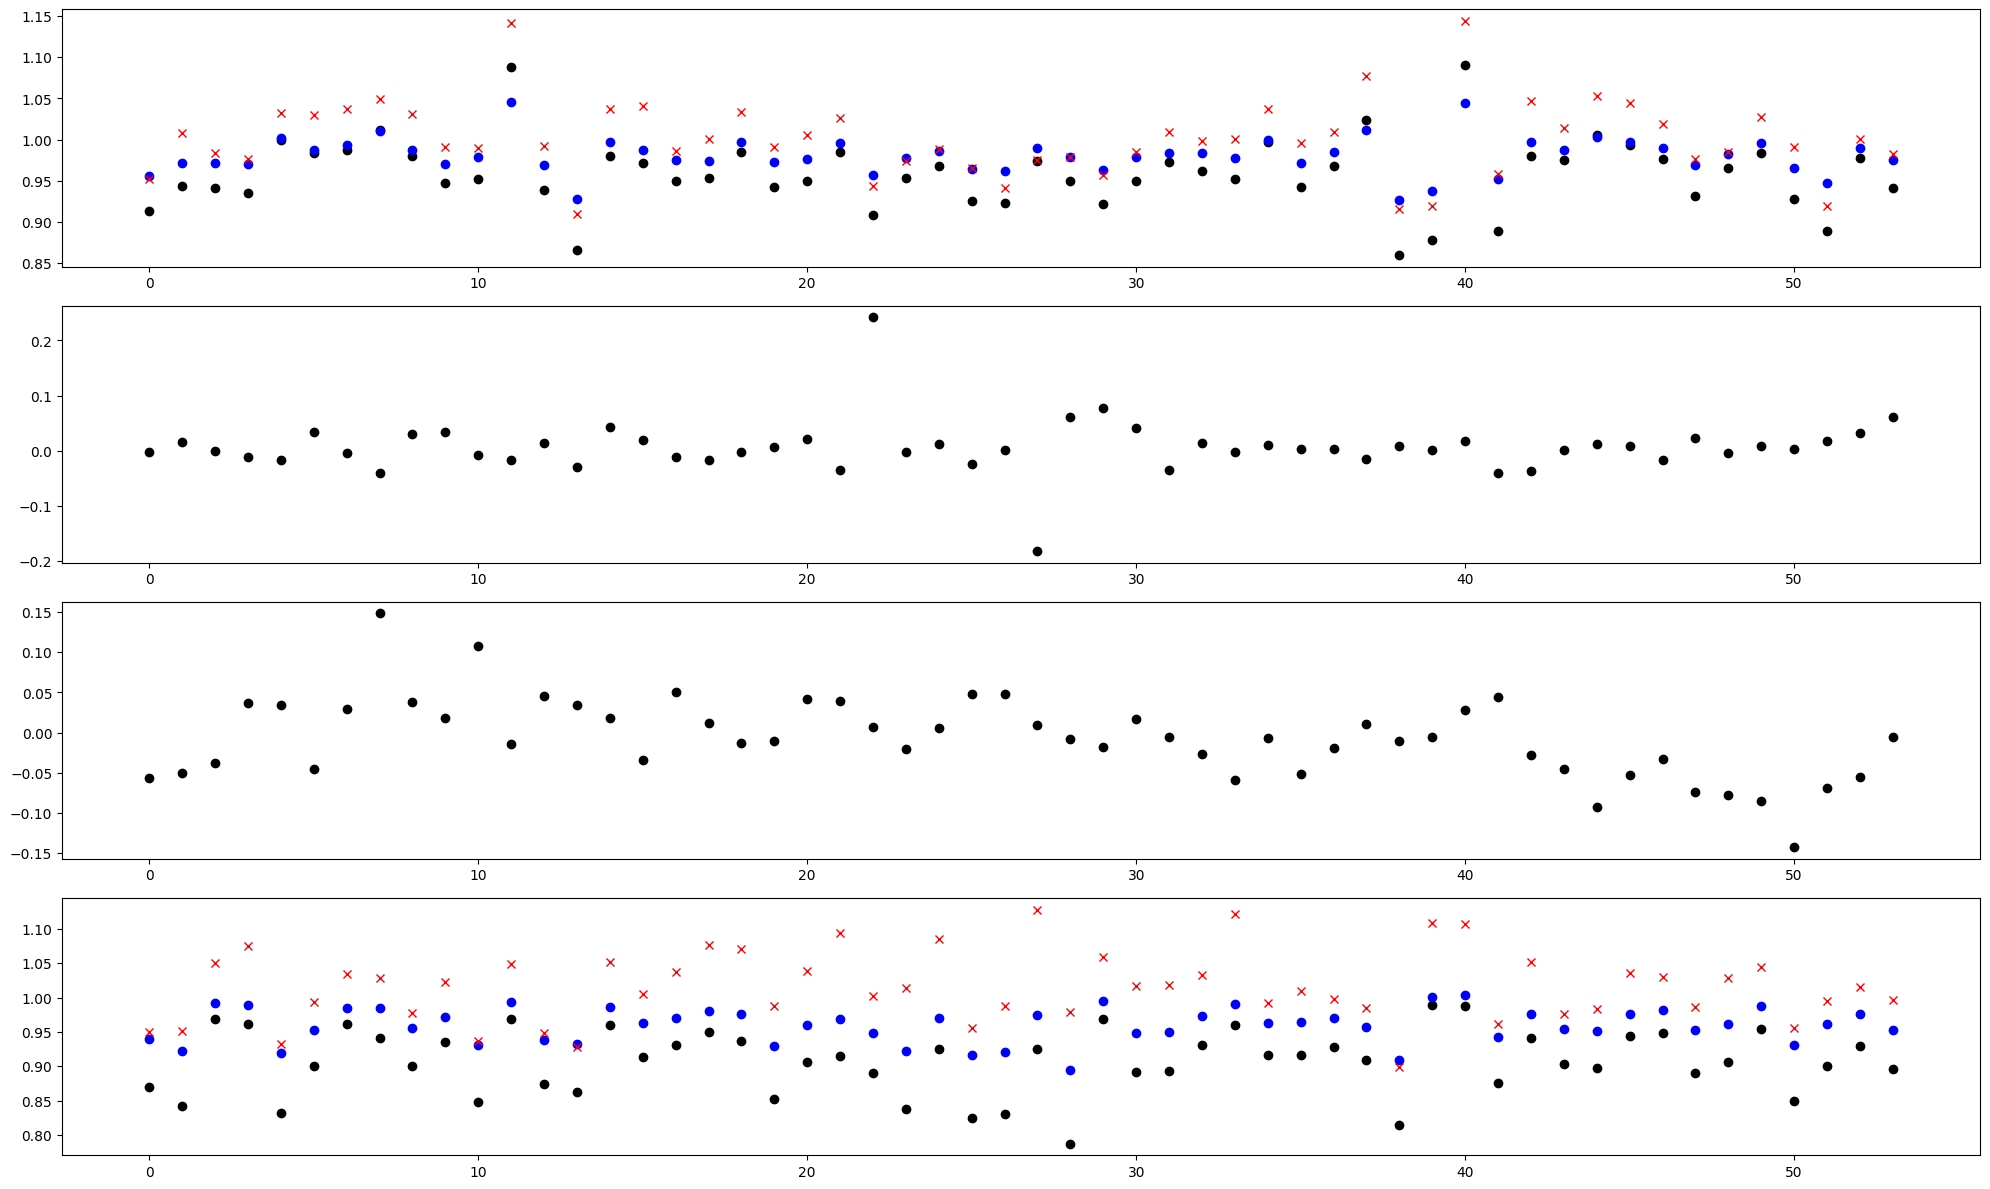

tensor(0.9587, dtype=torch.float64)
tensor(0.0437, dtype=torch.float64)

tensor(0.9074, dtype=torch.float64)
tensor(0.0470, dtype=torch.float64)



In [47]:
# Fit

def jacobian(n11, n33, n13, n14, n31, n32):
    return torch.stack([
        n11, n31, 0*n11, 0*n11,
        0*n11, 0*n11, n13, n33,
        n13, n33, n14**2/n33, 0*n11,
        n14, 0*n11, -n13*n14/n33, 0*n11,
        0*n11, n32**2/n11, n11, n31,
        0*n11, -n31*n32/n11, 0*n11, n32
    ]).reshape(-1, 4)

A = torch.vmap(jacobian)(value_n11, value_n33, value_n13, value_n14, value_n31, value_n32)
B = torch.stack([n11_estimate, n33_estimate, n13_estimate, n14_estimate, n31_estimate, n32_estimate]).T

gxx, gxy, gyx, gyy = torch.linalg.lstsq(A, B).solution.T

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), gxx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gxx_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), gxy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), gyx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), gyy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gyy_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(gxx.mean())
print(gxx.std())
print()

print(gyy.mean())
print(gyy.std())
print()

## Twiss (BEAM)

In [48]:
# Rescale TbT using estimated gxx and gyy from ratio

twiss.table.x = X.data/gxx.reshape(-1, 1)
twiss.table.y = Y.data/gyy.reshape(-1, 1)

In [49]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 64

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.80,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 39.6 s, sys: 1.91 s, total: 41.6 s
Wall time: 2min 54s


In [50]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

In [51]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

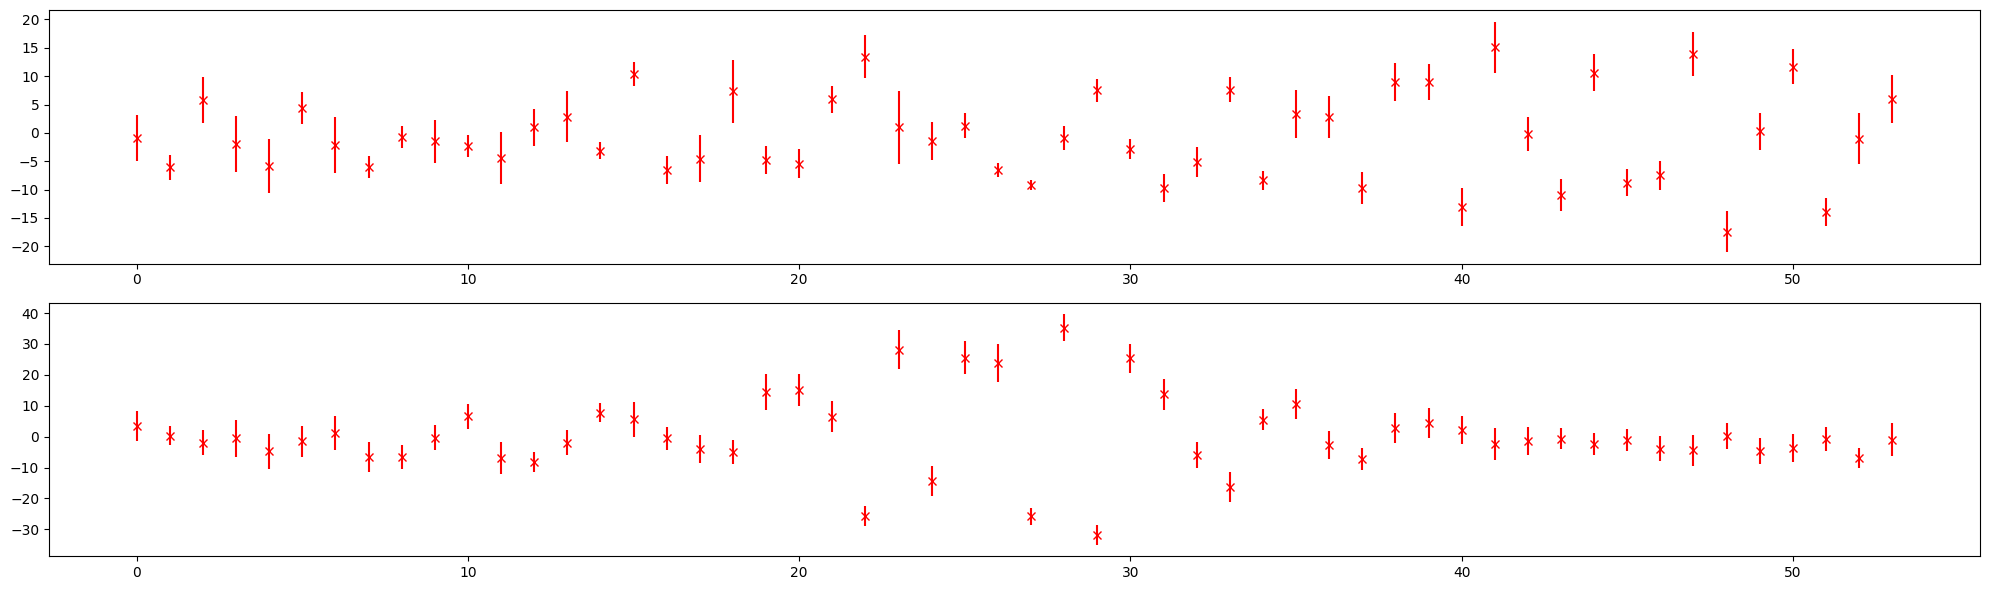

tensor(7.5286, dtype=torch.float64)
tensor(12.3232, dtype=torch.float64)



In [52]:
# Estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

tensor(0.1116, dtype=torch.float64)

tensor(0.2819, dtype=torch.float64)

tensor(0.0395, dtype=torch.float64)

tensor(0.0821, dtype=torch.float64)

tensor(0.3677, dtype=torch.float64)

tensor(0.4281, dtype=torch.float64)

tensor(0.2884, dtype=torch.float64)

tensor(0.0747, dtype=torch.float64)



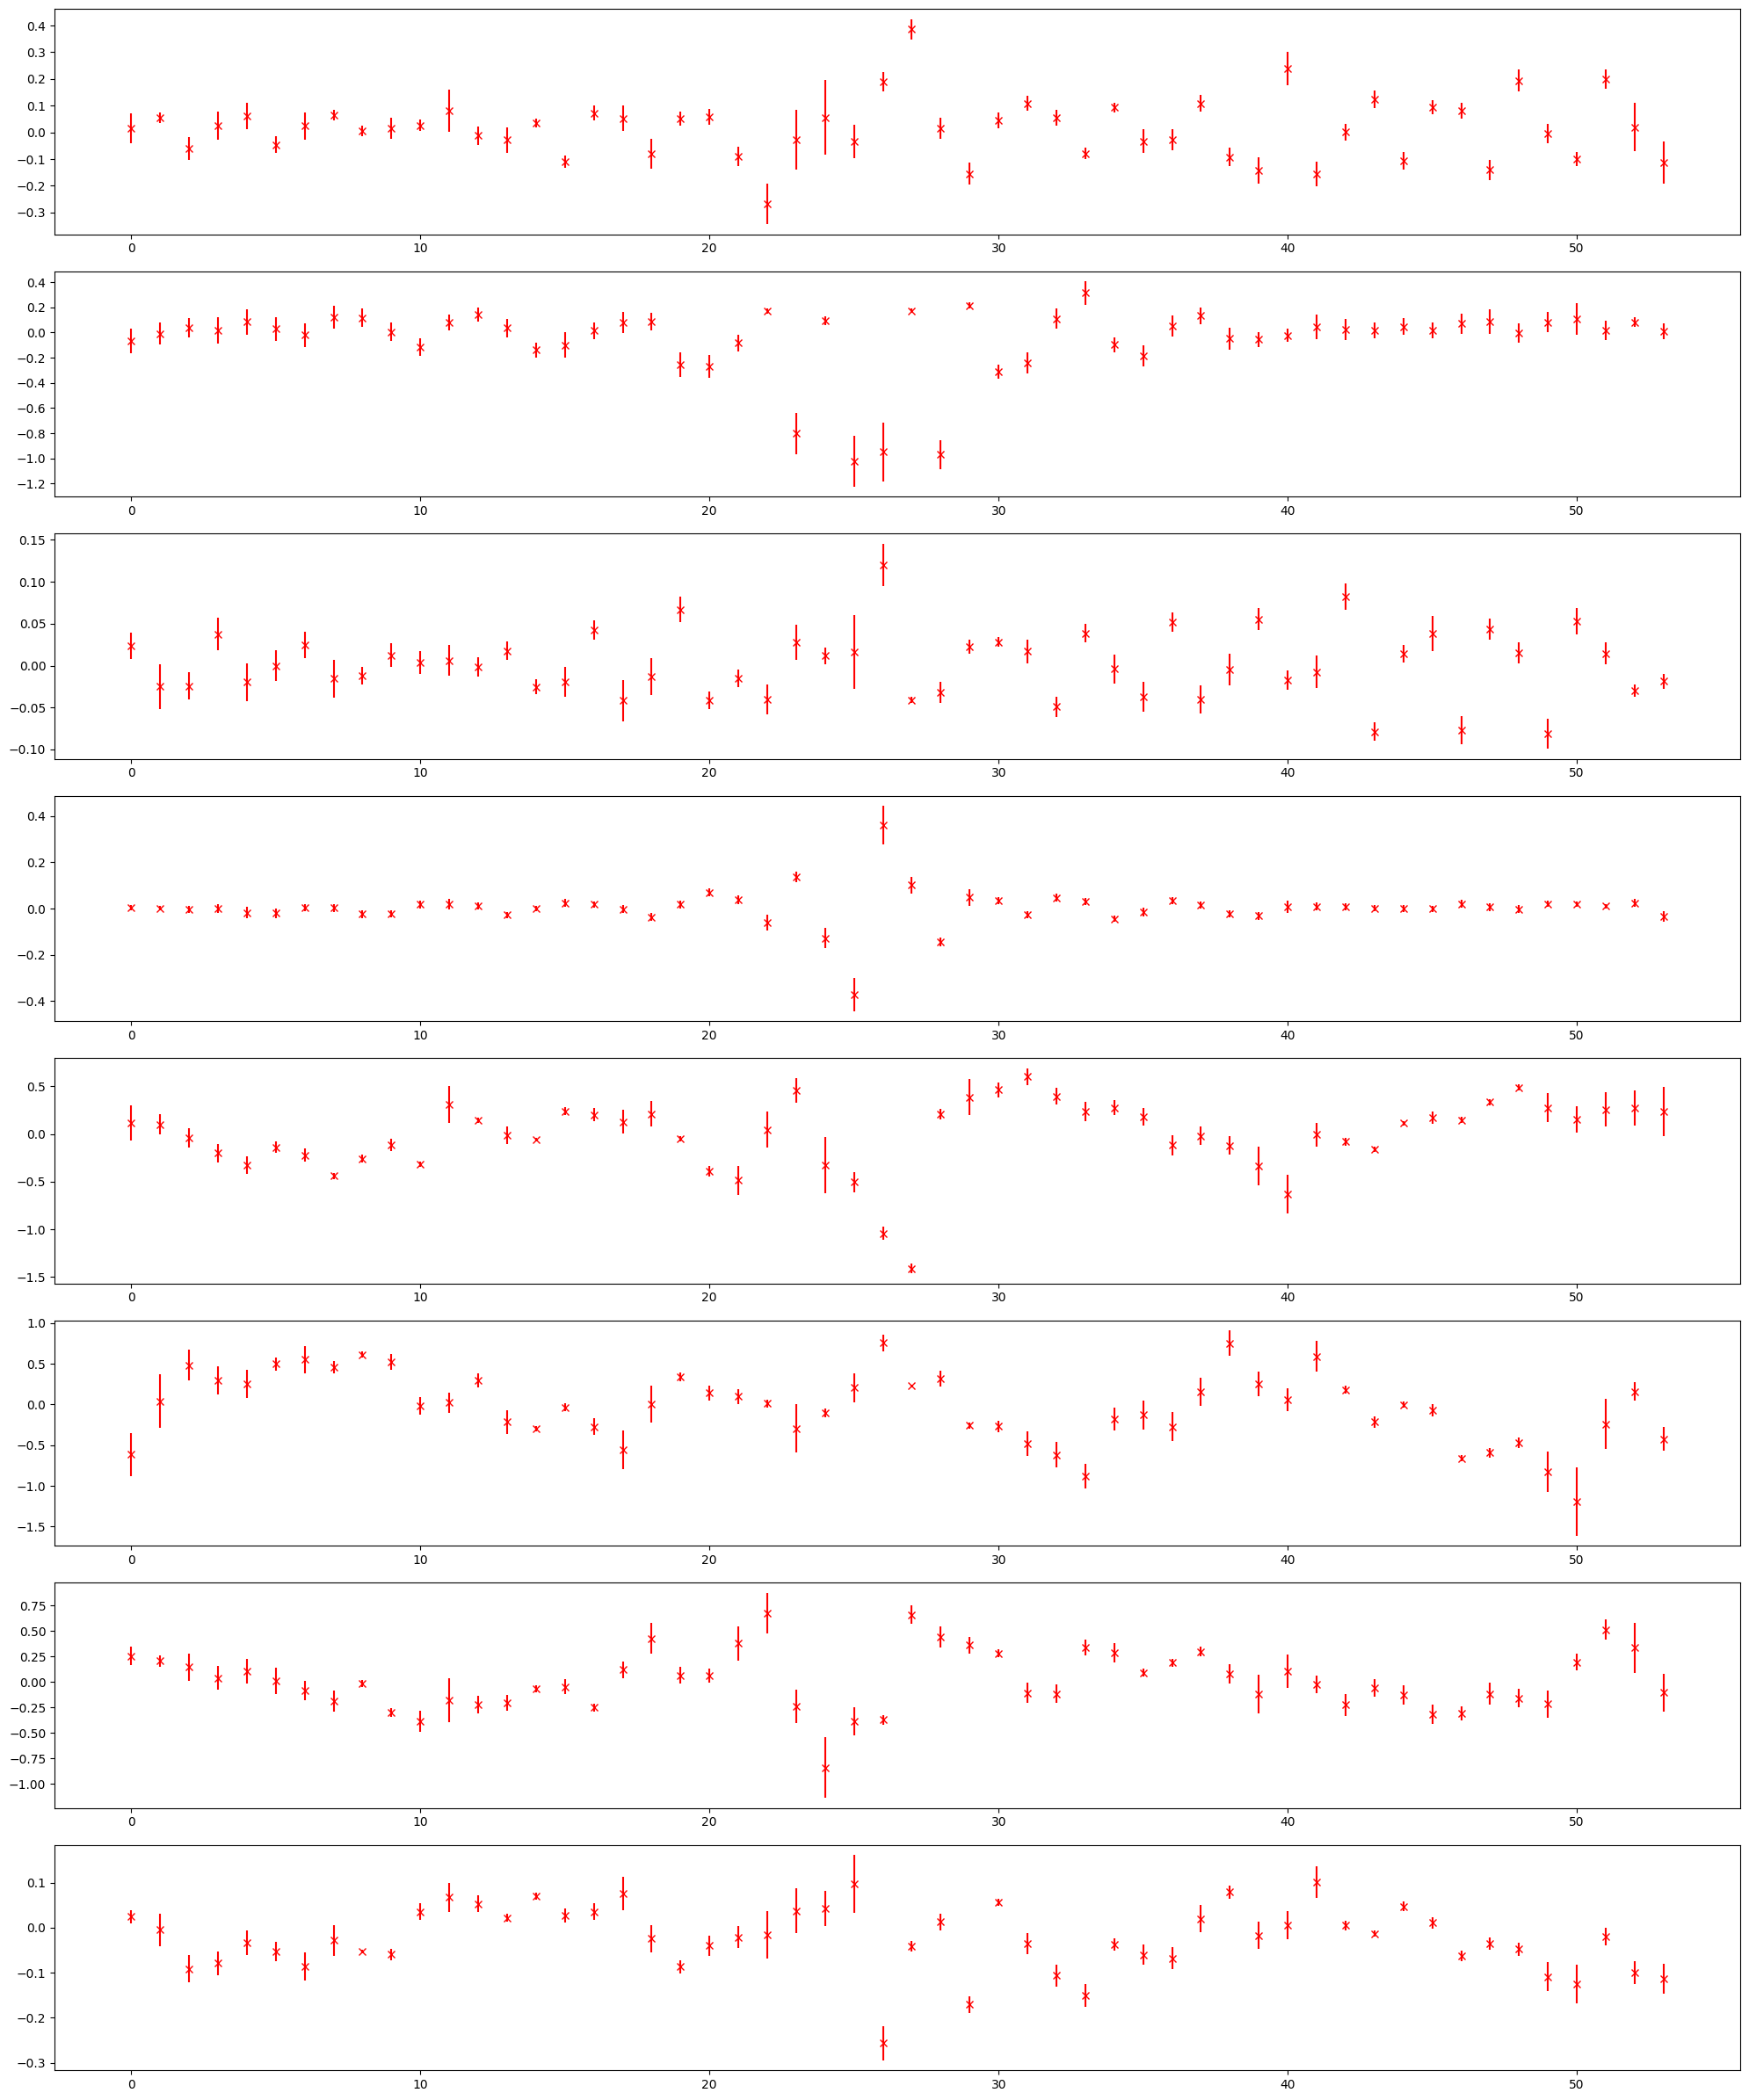

In [53]:
# Estimated twiss

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n11 - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n33 - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n21 - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n43 - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n13 - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n31 - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n14 - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
print(root_mean_square(n41 - value_n41))
print()

plt.tight_layout()
plt.show()

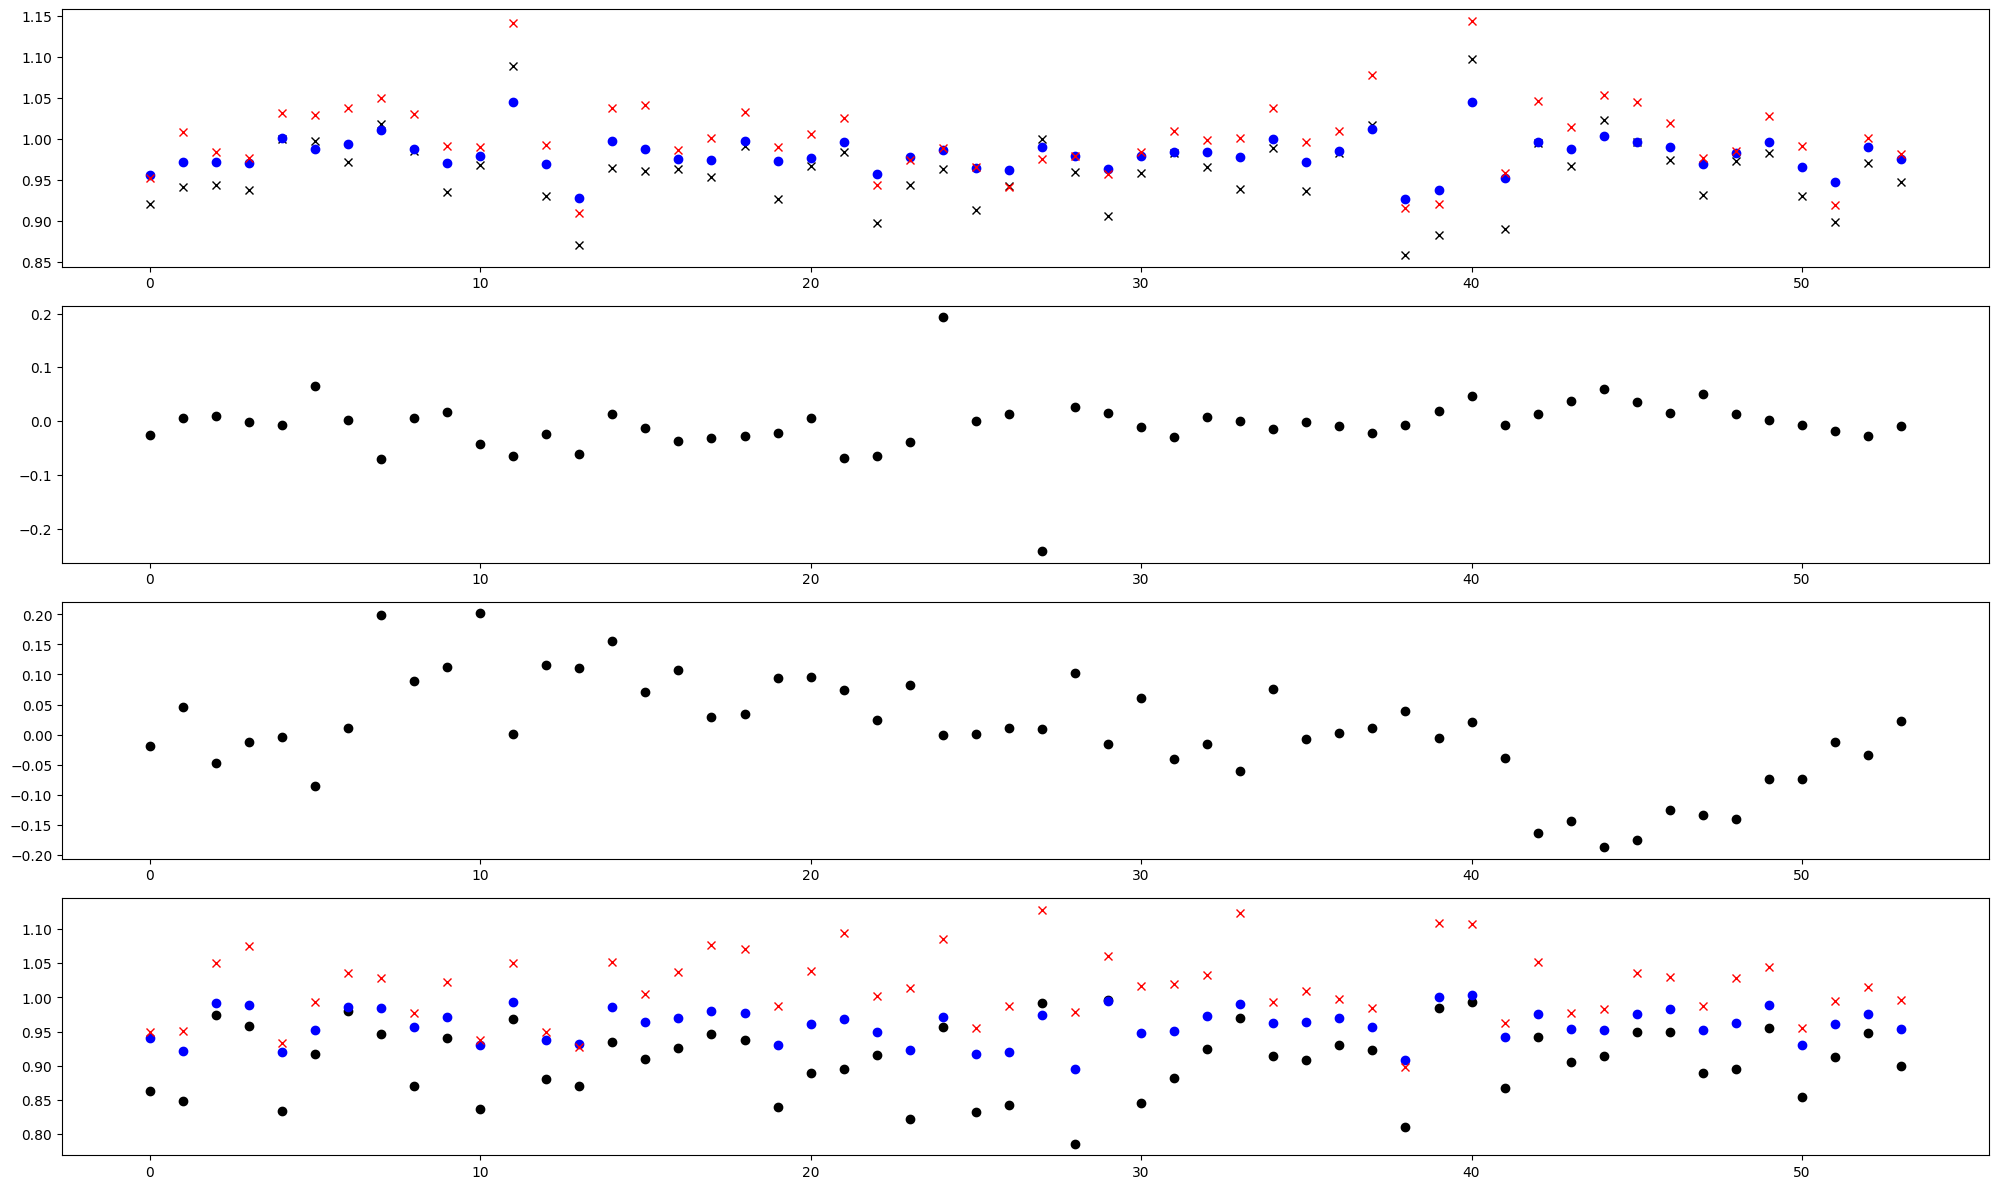

tensor(0.9599, dtype=torch.float64)
tensor(0.0454, dtype=torch.float64)

tensor(0.9091, dtype=torch.float64)
tensor(0.0517, dtype=torch.float64)



In [54]:
# Fit

def jacobian(n11, n33, n13, n14, n31, n32):
    return torch.stack([
        n11, n31, 0*n11, 0*n11,
        0*n11, 0*n11, n13, n33,
        n13, n33, n14**2/n33, 0*n11,
        n14, 0*n11, -n13*n14/n33, 0*n11,
        0*n11, n32**2/n11, n11, n31,
        0*n11, -n31*n32/n11, 0*n11, n32
    ]).reshape(-1, 4)

A = torch.vmap(jacobian)(value_n11, value_n33, value_n13, value_n14, value_n31, value_n32)
B = torch.stack([n11_estimate, n33_estimate, n13_estimate, n14_estimate, n31_estimate, n32_estimate]).T

gxx, gxy, gyx, gyy = torch.linalg.lstsq(A, B).solution.T

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), gxx.cpu().numpy(), fmt=' ', marker='x', color='black')
ax.errorbar(range(model.monitor_count), gxx_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), gxy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), gyx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), gyy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gyy_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(gxx.mean())
print(gxx.std())
print()

print(gyy.mean())
print(gyy.std())
print()

## Twiss (BEAM & full rescale)

In [55]:
# Rescale TbT using estimated gxx and gyy from ratio

# qx->-((gyy qx_bpm-gxy qy_bpm)/(gxy gyx-gxx gyy))
# qy->-((-gyx qx_bpm+gxx qy_bpm)/(gxy gyx-gxx gyy))

twiss.table.x = -((gyy.reshape(-1, 1)*X.data-gxy.reshape(-1, 1)*Y.data)/(gxy*gyx-gxx*gyy).reshape(-1, 1))
twiss.table.y = -((-gyx.reshape(-1, 1)*X.data+gxx.reshape(-1, 1)*Y.data)/(gxy*gyx-gxx*gyy).reshape(-1, 1))

In [56]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 64

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 39.3 s, sys: 1.94 s, total: 41.3 s
Wall time: 2min 44s


In [57]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

In [58]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

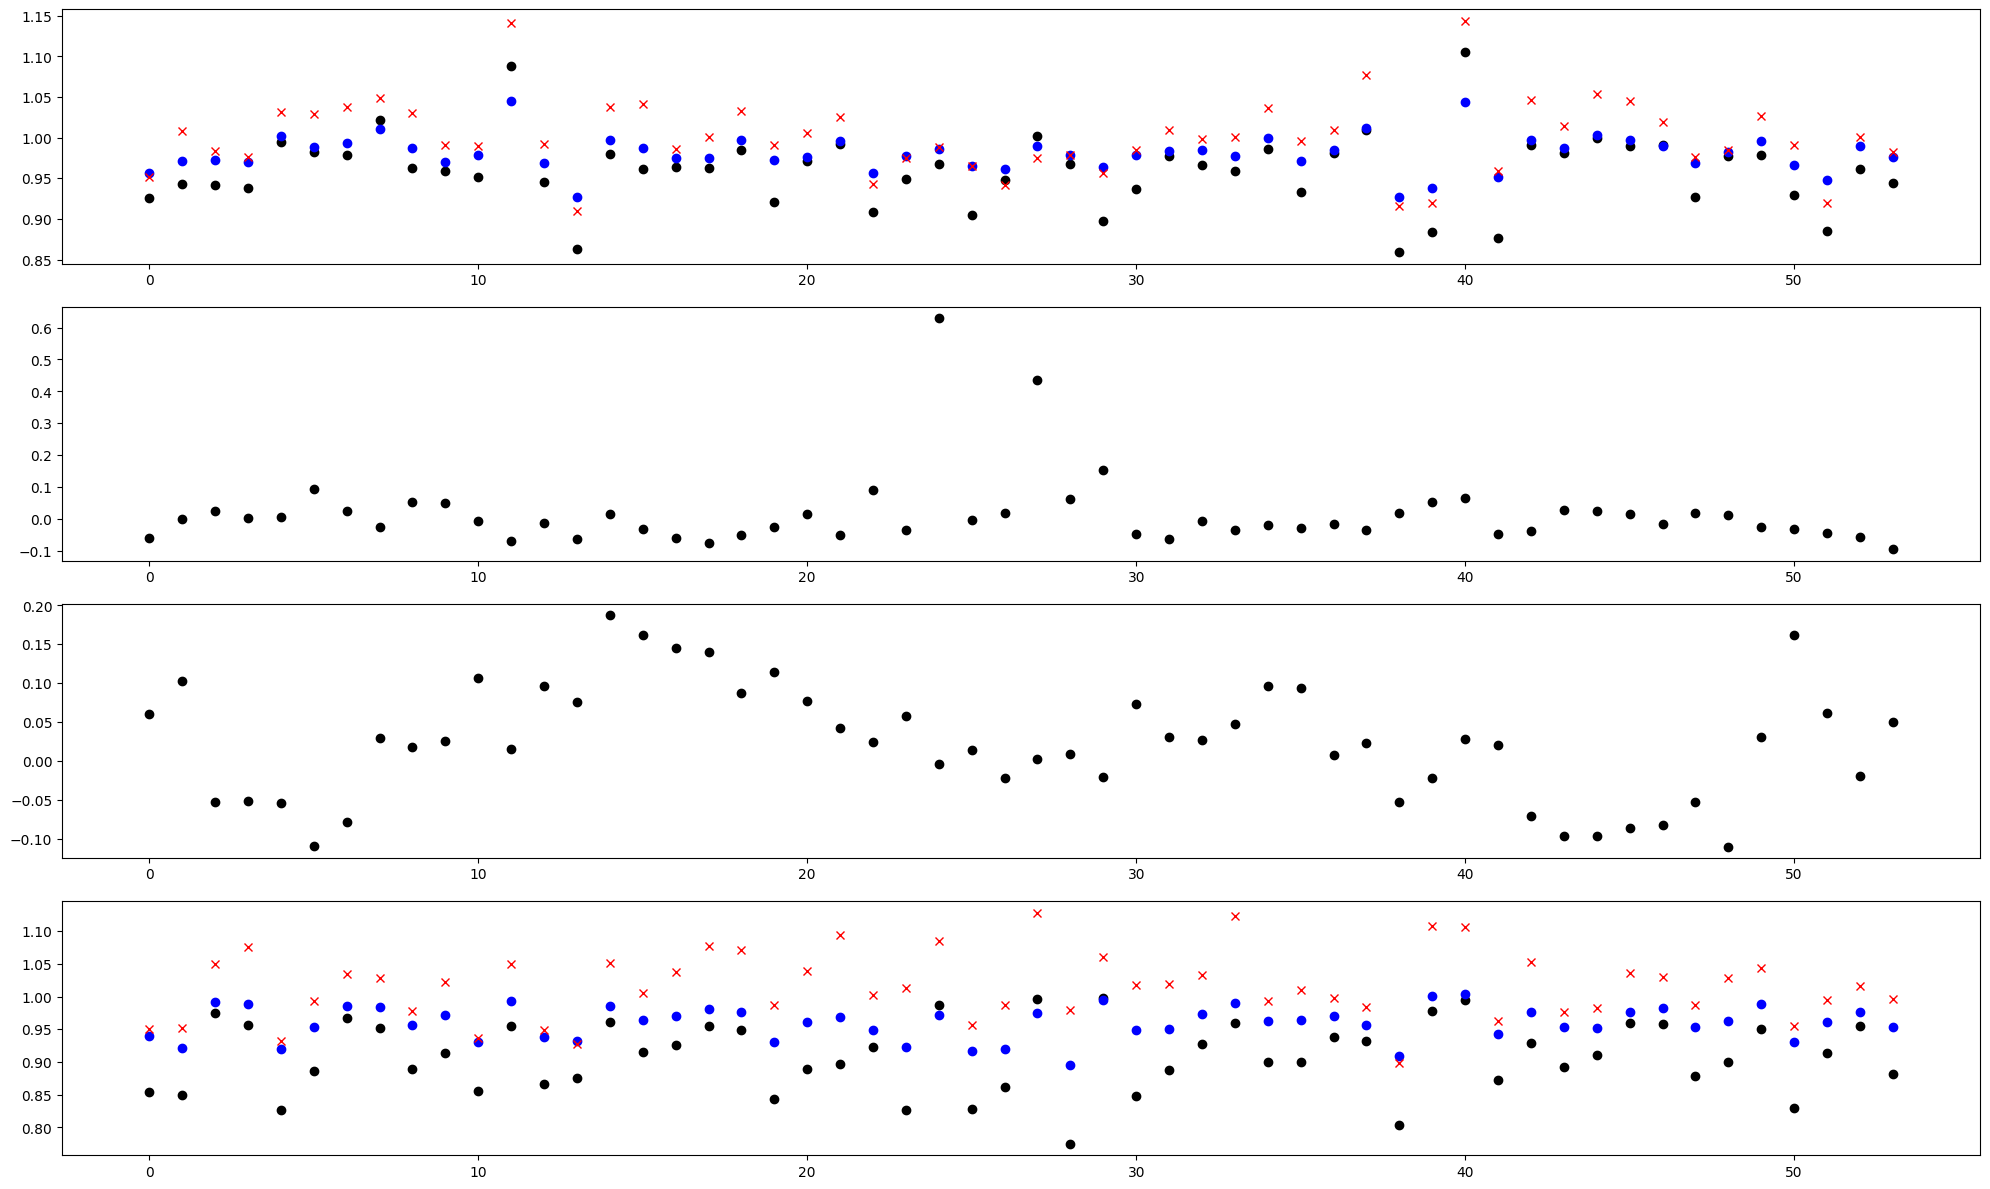

tensor(0.9595, dtype=torch.float64)
tensor(0.0460, dtype=torch.float64)

tensor(0.9084, dtype=torch.float64)
tensor(0.0535, dtype=torch.float64)



In [59]:
# Fit

def jacobian(n11, n33, n13, n14, n31, n32):
    return torch.stack([
        n11, n31, 0*n11, 0*n11,
        0*n11, 0*n11, n13, n33,
        n13, n33, n14**2/n33, 0*n11,
        n14, 0*n11, -n13*n14/n33, 0*n11,
        0*n11, n32**2/n11, n11, n31,
        0*n11, -n31*n32/n11, 0*n11, n32
    ]).reshape(-1, 4)

A = torch.vmap(jacobian)(value_n11, value_n33, value_n13, value_n14, value_n31, value_n32)
B = torch.stack([n11_estimate, n33_estimate, n13_estimate, n14_estimate, n31_estimate, n32_estimate]).T

gxx, gxy, gyx, gyy = torch.linalg.lstsq(A, B).solution.T

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), gxx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gxx_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), gxy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), gyx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), gyy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gyy_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(gxx.mean())
print(gxx.std())
print()

print(gyy.mean())
print(gyy.std())
print()

## Twiss (BPM & fit)

In [60]:
# TbT is not rescaled, invariants are fixed, tranport matrices are modified using estimated calibrations

In [61]:
twiss.table.x = X.data
twiss.table.y = Y.data

In [62]:
# Set transformation matrices to BPM frame
# M12 -> G2 @ M12 @ G1^-1

bpm_estimate = torch.vmap(calibration)(gxx, gxy, gyx, gyy)

In [63]:
# Define modified transport matrices

def transport(probe, other, calibration):

    if isinstance(probe, int):
        i_probe = torch.tensor([probe], dtype=torch.int64, device=model.device)

    if isinstance(other, int):
        i_other = torch.tensor([other], dtype=torch.int64, device=model.device)
    
    i_probe = mod(i_probe, model.size).to(torch.int64)
    i_other = mod(i_other, model.size).to(torch.int64)

    table = dict(zip(model.monitor_index, range(model.monitor_count)))
    
    return calibration[table[i_other.item()]] @ model.matrix(probe, other) @ calibration[table[i_probe.item()]].inverse()

In [64]:
%%time

# Estimate twiss from invariant fit using estimated calibrations (fixed invariants)

count = 16

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 lambda x, y: transport(x, y, bpm_estimate),        # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 13.4 s, sys: 609 ms, total: 14 s
Wall time: 48 s


In [65]:
# Process twiss

bvalue_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

bvalue_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

bvalue_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

bvalue_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

bvalue_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

bvalue_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

bvalue_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

bvalue_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

bvalue_n11, error_n11 = twiss.process(bvalue_n11, error_n11)
bvalue_n33, error_n33 = twiss.process(bvalue_n33, error_n33)
bvalue_n21, error_n21 = twiss.process(bvalue_n21, error_n21)
bvalue_n43, error_n43 = twiss.process(bvalue_n43, error_n43)
bvalue_n13, error_n13 = twiss.process(bvalue_n13, error_n13)
bvalue_n31, error_n31 = twiss.process(bvalue_n31, error_n31)
bvalue_n14, error_n14 = twiss.process(bvalue_n14, error_n14)
bvalue_n41, error_n41 = twiss.process(bvalue_n41, error_n41)

bvalue = torch.stack([bvalue_n11, bvalue_n33, bvalue_n21, bvalue_n43, bvalue_n13, bvalue_n31, bvalue_n14, bvalue_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(bvalue, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

In [66]:
# Set all normalization matrix elements

bvalue_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(bvalue_n11, bvalue_n33, bvalue_n21, bvalue_n43, bvalue_n13, bvalue_n31, bvalue_n14, bvalue_n41)])

bvalue_n11 = bvalue_normal[:, 0, 0]
bvalue_n12 = bvalue_normal[:, 0, 1]
bvalue_n13 = bvalue_normal[:, 0, 2]
bvalue_n14 = bvalue_normal[:, 0, 3]

bvalue_n21 = bvalue_normal[:, 1, 0]
bvalue_n22 = bvalue_normal[:, 1, 1]
bvalue_n23 = bvalue_normal[:, 1, 2]
bvalue_n24 = bvalue_normal[:, 1, 3]

bvalue_n31 = bvalue_normal[:, 2, 0]
bvalue_n32 = bvalue_normal[:, 2, 1]
bvalue_n33 = bvalue_normal[:, 2, 2]
bvalue_n34 = bvalue_normal[:, 2, 3]

bvalue_n41 = bvalue_normal[:, 3, 0]
bvalue_n42 = bvalue_normal[:, 3, 1]
bvalue_n43 = bvalue_normal[:, 3, 2]
bvalue_n44 = bvalue_normal[:, 3, 3]

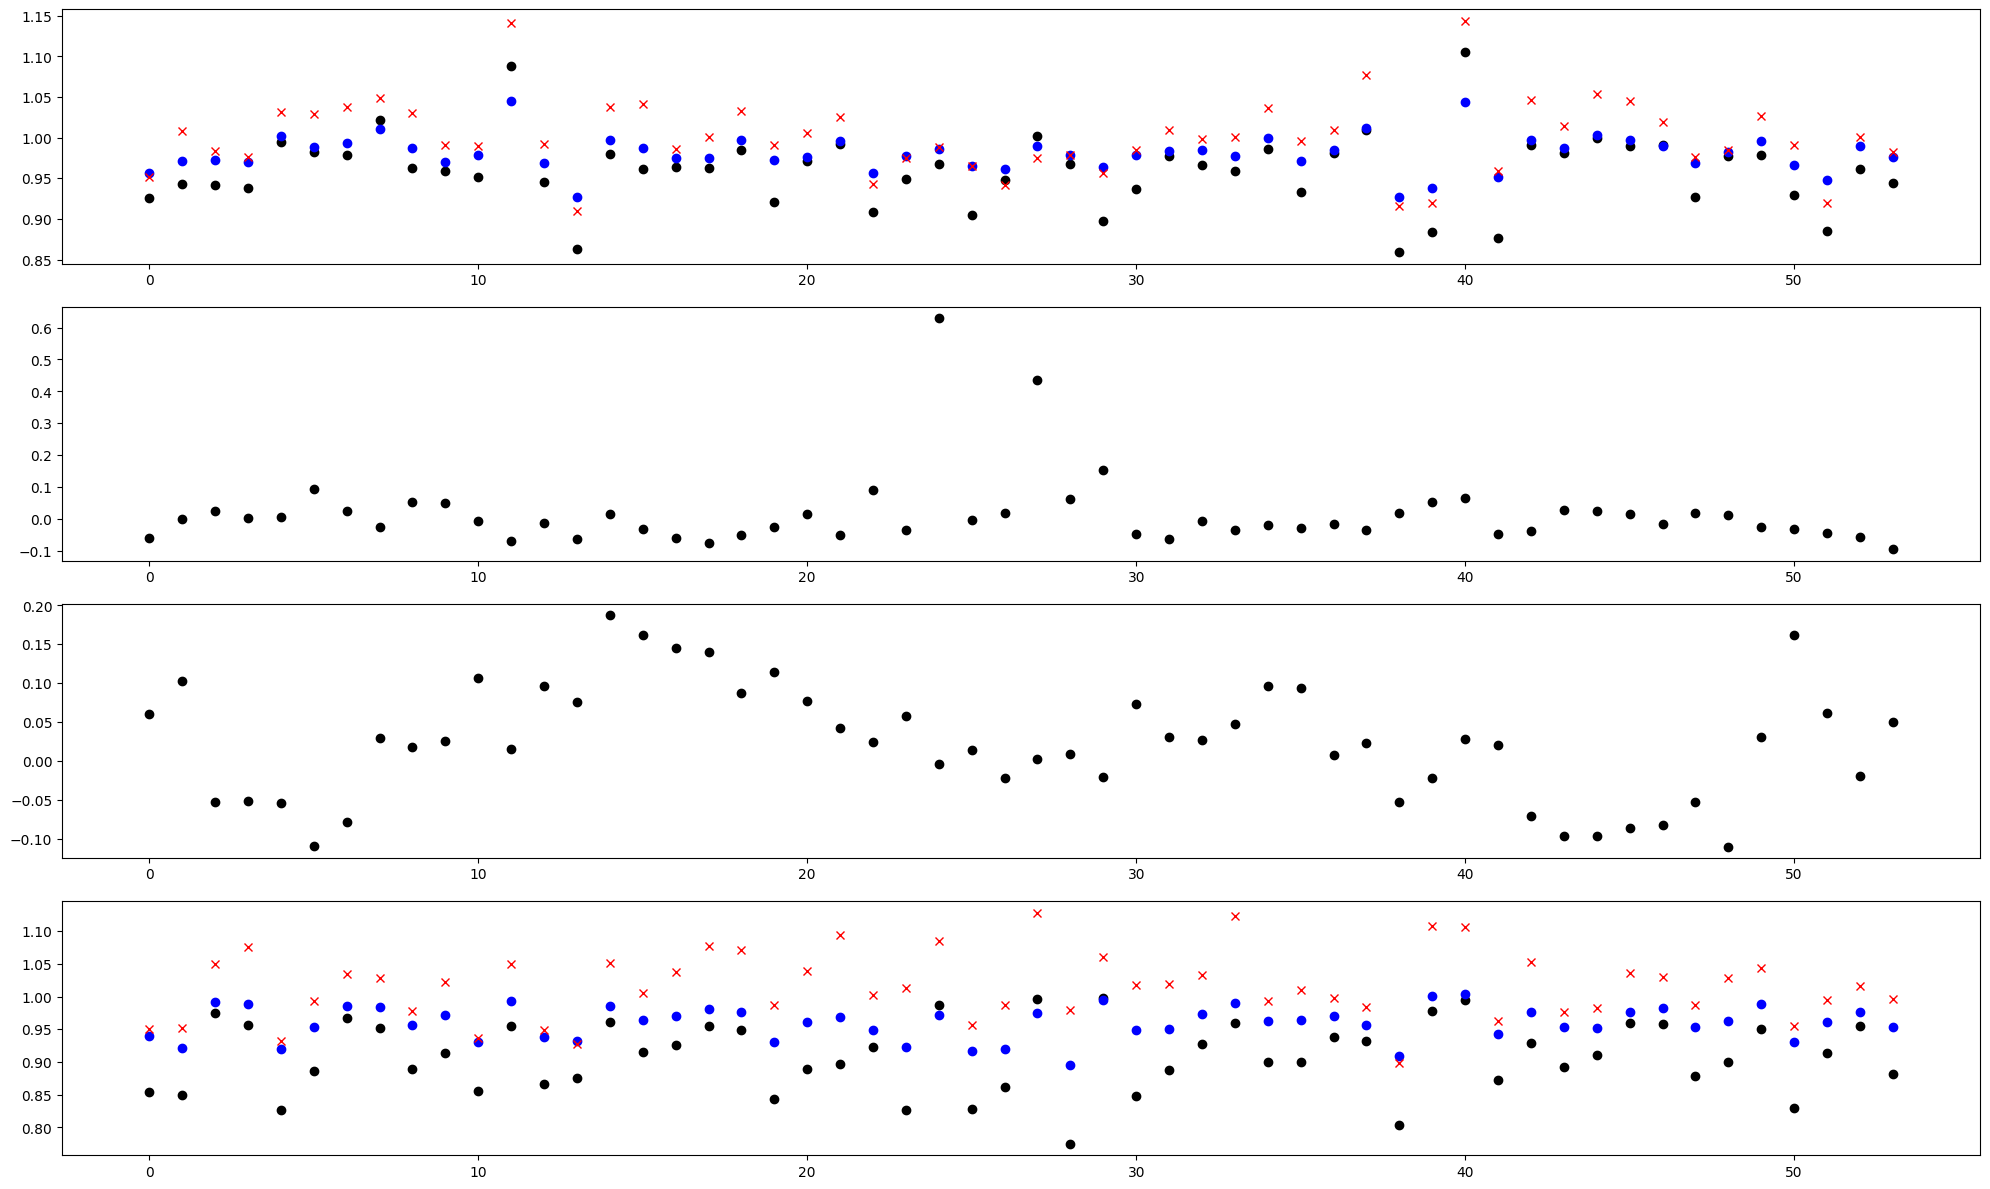

tensor(0.9595, dtype=torch.float64)
tensor(0.0460, dtype=torch.float64)

tensor(0.9084, dtype=torch.float64)
tensor(0.0535, dtype=torch.float64)



In [67]:
# Fit

def jacobian(n11, n33, n13, n14, n31, n32):
    return torch.stack([
        n11, n31, 0*n11, 0*n11,
        0*n11, 0*n11, n13, n33,
        n13, n33, n14**2/n33, 0*n11,
        n14, 0*n11, -n13*n14/n33, 0*n11,
        0*n11, n32**2/n11, n11, n31,
        0*n11, -n31*n32/n11, 0*n11, n32
    ]).reshape(-1, 4)

A = torch.vmap(jacobian)(value_n11, value_n33, value_n13, value_n14, value_n31, value_n32)
B = torch.stack([n11_estimate, n33_estimate, n13_estimate, n14_estimate, n31_estimate, n32_estimate]).T

gxx, gxy, gyx, gyy = torch.linalg.lstsq(A, B).solution.T

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), gxx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gxx_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), gxy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), gyx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), gyy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gyy_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(gxx.mean())
print(gxx.std())
print()

print(gyy.mean())
print(gyy.std())
print()

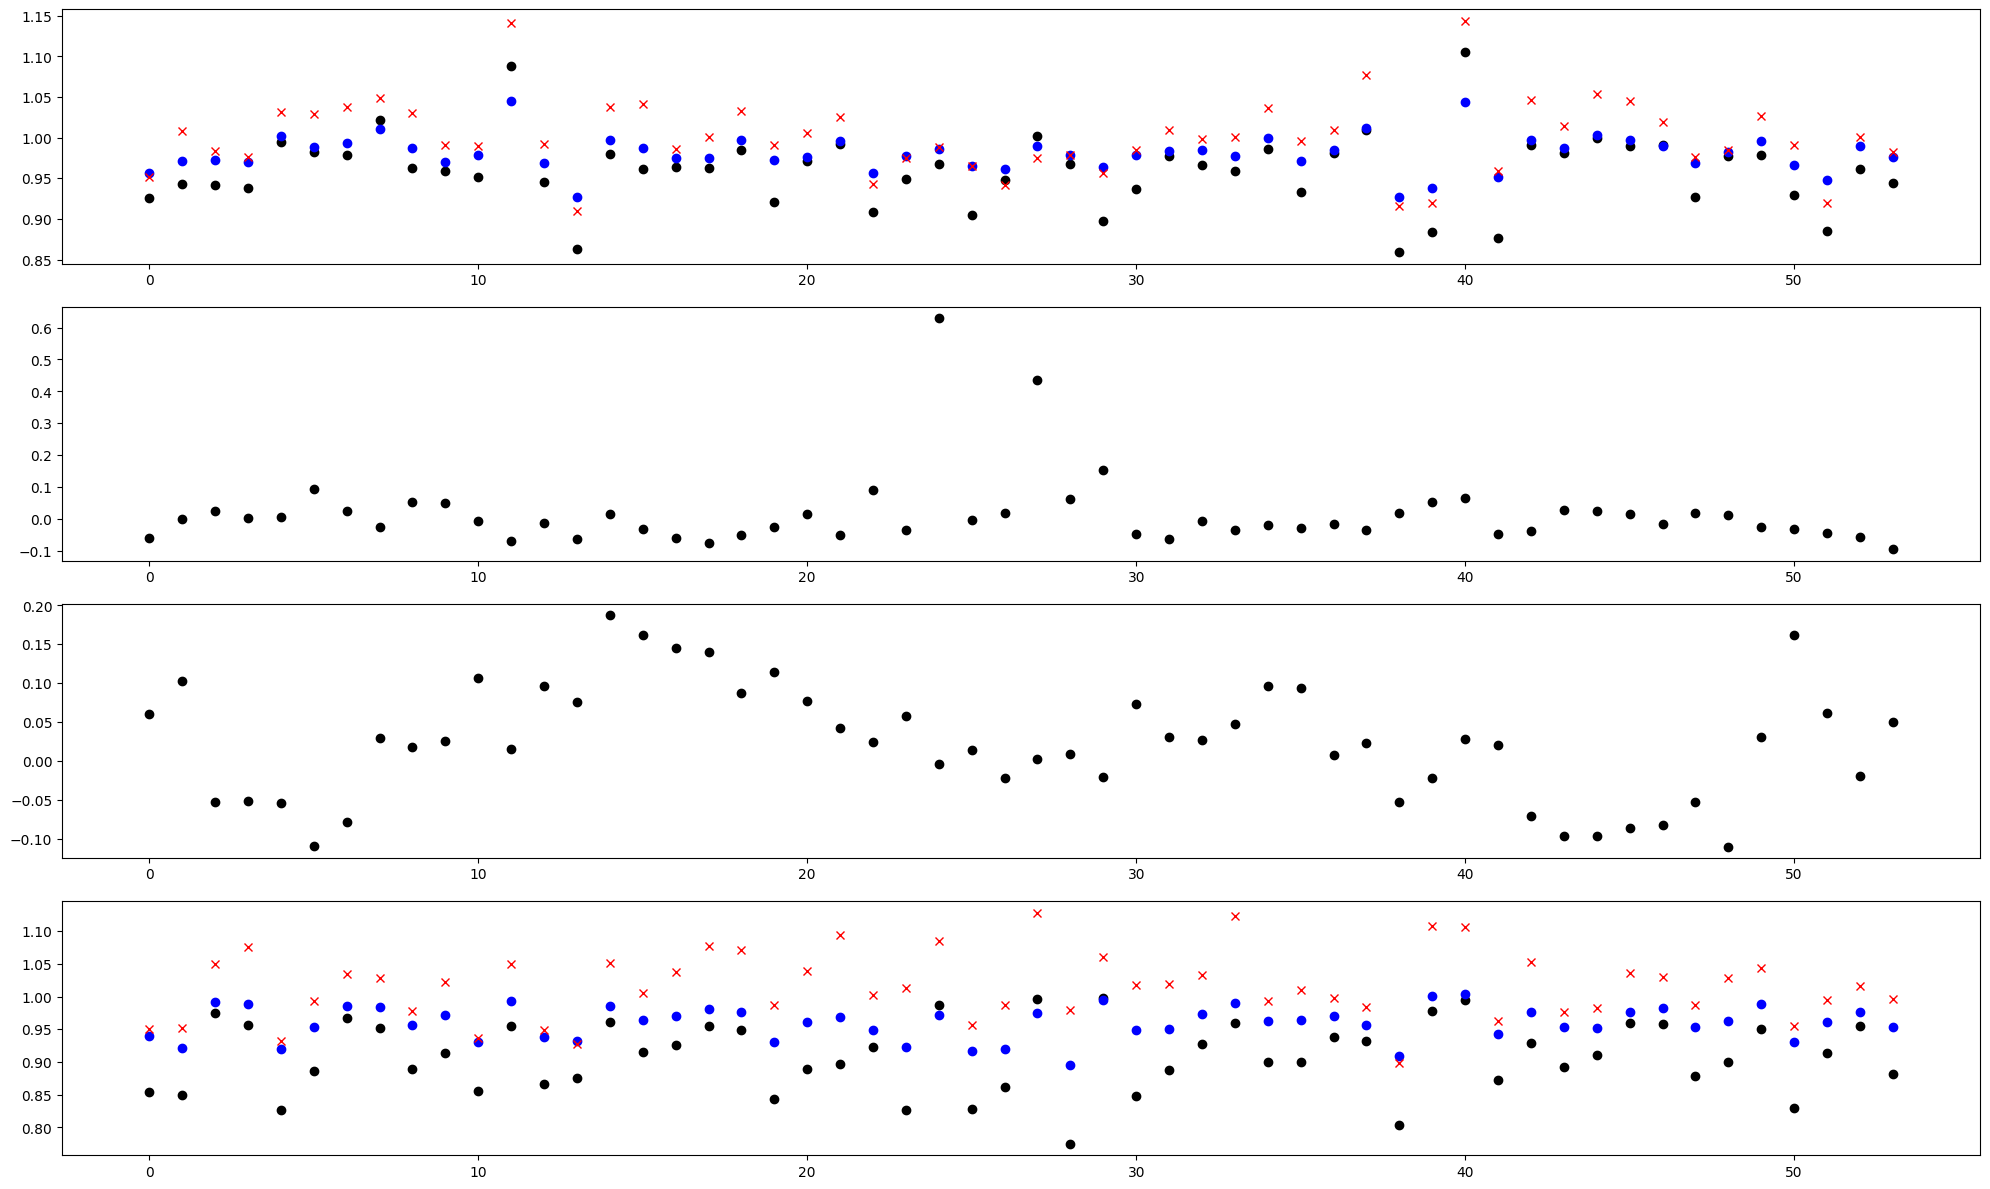

tensor(0.9595, dtype=torch.float64)
tensor(0.0460, dtype=torch.float64)

tensor(0.9084, dtype=torch.float64)
tensor(0.0535, dtype=torch.float64)



In [68]:
# Fit calibrations (beam frame twiss from fit with modified transport)

def jacobian(n11, n33, n13, n14, n31, n32):
    return torch.stack([
        n11, n31, 0*n11, 0*n11,
        0*n11, 0*n11, n13, n33,
        n13, n33, n14**2/n33, 0*n11,
        n14, 0*n11, -n13*n14/n33, 0*n11,
        0*n11, n32**2/n11, n11, n31,
        0*n11, -n31*n32/n11, 0*n11, n32
    ]).reshape(-1, 4)

gxx, gxy, gyx, gyy = torch.linalg.lstsq(A, B).solution.T

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), gxx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gxx_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), gxy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), gyx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), gyy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gyy_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(gxx.mean())
print(gxx.std())
print()

print(gyy.mean())
print(gyy.std())
print()

In [69]:
def transform(x,n00,n02,n03,n10,n11,n12,n13,n20,n21,n22,n30,n31,n32,n33):
    gxx, gxy, gyx, gyy = x
    return torch.stack([
    (gxx * n00 + gxy * n20) * torch.sqrt(1 + (gxy**2 * n21**2) / (gxx * n00 + gxy * n20)**2),
    (gxx * gyx * (n02**2 + n03**2) + (gxy * gyx + gxx * gyy) * n02 * n22 + gxy * gyy * n22**2) / ((gyx * n02 + gyy * n22) * torch.sqrt(1 + (gyx**2 * n03**2) / (gyx * n02 + gyy * n22)**2)),
    ((-gxy * gyx + gxx * gyy) * n03 * n22) / ((gyx * n02 + gyy * n22) * torch.sqrt(1 + (gyx**2 * n03**2) / (gyx * n02 + gyy * n22)**2)),
    (gxx * n00 * (gyy * n10 - gyx * n30) + gxy * (gyy * (n10 * n20 + n11 * n21) - gyx * (n20 * n30 + n21 * n31))) / ((-gxy * gyx + gxx * gyy) * (gxx * n00 + gxy * n20) * torch.sqrt(1 + (gxy**2 * n21**2) / (gxx * n00 + gxy * n20)**2)),
    (gxx * n00 * (gyy * n11 - gyx * n31) + gxy * (gyy * (n11 * n20 - n10 * n21) + gyx * (n21 * n30 - n20 * n31))) / ((-gxy * gyx + gxx * gyy) * (gxx * n00 + gxy * n20) * torch.sqrt(1 + (gxy**2 * n21**2) / (gxx * n00 + gxy * n20)**2)),
    (-gyy**2 * n12 * n22 - gyx * gyy * (n02 * n12 + n03 * n13 - n22 * n32) + gyx**2 * (n02 * n32 + n03 * n33)) / ((gxy * gyx - gxx * gyy) * (gyx * n02 + gyy * n22) * torch.sqrt(1 + (gyx**2 * n03**2) / (gyx * n02 + gyy * n22)**2)),
    (-gyy**2 * n13 * n22 + gyx**2 * (-n03 * n32 + n02 * n33) + gyx * gyy * (n03 * n12 - n02 * n13 + n22 * n33)) / ((gxy * gyx - gxx * gyy) * (gyx * n02 + gyy * n22) * torch.sqrt(1 + (gyx**2 * n03**2) / (gyx * n02 + gyy * n22)**2)),
    ((gxx * n00 + gxy * n20) * (gyx * n00 + gyy * n20) + gxy * gyy * n21**2) / ((gxx * n00 + gxy * n20) * torch.sqrt(1 + (gxy**2 * n21**2) / (gxx * n00 + gxy * n20)**2)),
    ((-gxy * gyx + gxx * gyy) * n00 * n21) / ((gxx * n00 + gxy * n20) * torch.sqrt(1 + (gxy**2 * n21**2) / (gxx * n00 + gxy * n20)**2)),
    (gyx * n02 + gyy * n22) * torch.sqrt(1 + (gyx**2 * n03**2) / (gyx * n02 + gyy * n22)**2),
    (-gxy**2 * (n10 * n20 + n11 * n21) + gxx**2 * n00 * n30 + gxx * gxy * (-n00 * n10 + n20 * n30 + n21 * n31)) / ((-gxy * gyx + gxx * gyy) * (gxx * n00 + gxy * n20) * torch.sqrt(1 + (gxy**2 * n21**2) / (gxx * n00 + gxy * n20)**2)),
    (-gxy * (gxy * (n11 * n20 - n10 * n21) + gxx * (n00 * n11 + n21 * n30)) + gxx * (gxx * n00 + gxy * n20) * n31) / ((-gxy * gyx + gxx * gyy) * (gxx * n00 + gxy * n20) * torch.sqrt(1 + (gxy**2 * n21**2) / (gxx * n00 + gxy * n20)**2)),
    (gxy * (gyx * (n02 * n12 + n03 * n13) + gyy * n12 * n22) - gxx * ((gyx * n02 + gyy * n22) * n32 + gyx * n03 * n33)) / ((gxy * gyx - gxx * gyy) * (gyx * n02 + gyy * n22) * torch.sqrt(1 + (gyx**2 * n03**2) / (gyx * n02 + gyy * n22)**2)),
    (gxy * (gyx * (-n03 * n12 + n02 * n13) + gyy * n13 * n22) + gxx * (gyx * n03 * n32 - (gyx * n02 + gyy * n22) * n33)) / ((gxy * gyx - gxx * gyy) * (gyx * n02 + gyy * n22) * torch.sqrt(1 + (gyx**2 * n03**2) / (gyx * n02 + gyy * n22)**2))])

In [70]:
# Fit for each bpm

data = []

for i in range(54):

    nn = torch.stack([value_n11[i],value_n13[i],value_n14[i],value_n21[i],value_n22[i],value_n23[i],value_n24[i],value_n31[i],value_n32[i],value_n33[i],value_n41[i],value_n42[i],value_n43[i],value_n44[i]])
    yn = torch.stack([n11_estimate[i],bvalue_n13[i],n14_estimate[i],bvalue_n21[i],bvalue_n22[i],bvalue_n23[i],bvalue_n24[i],bvalue_n31[i],n32_estimate[i],n33_estimate[i],bvalue_n41[i],bvalue_n42[i],bvalue_n43[i],bvalue_n44[i]])
    
    fn = lambda x: transform(x, *nn)
    
    xi = torch.tensor([gxx[i].item(), gxy[i].item(), gyx[i].item(), gyy[i].item()], dtype=dtype, device=device, requires_grad=True)
    
    optimizer = torch.optim.Adam([xi], lr=0.01)
    loss = torch.nn.MSELoss()
    
    for epoch in range(512):
        
        yi = fn(xi)
        
        error = loss(yi, yn)
        
        optimizer.zero_grad()
        error.backward()
        optimizer.step()
        
    data.append(xi.detach().clone())

Gxx, Gxy, Gyx, Gyy = torch.stack(data).T

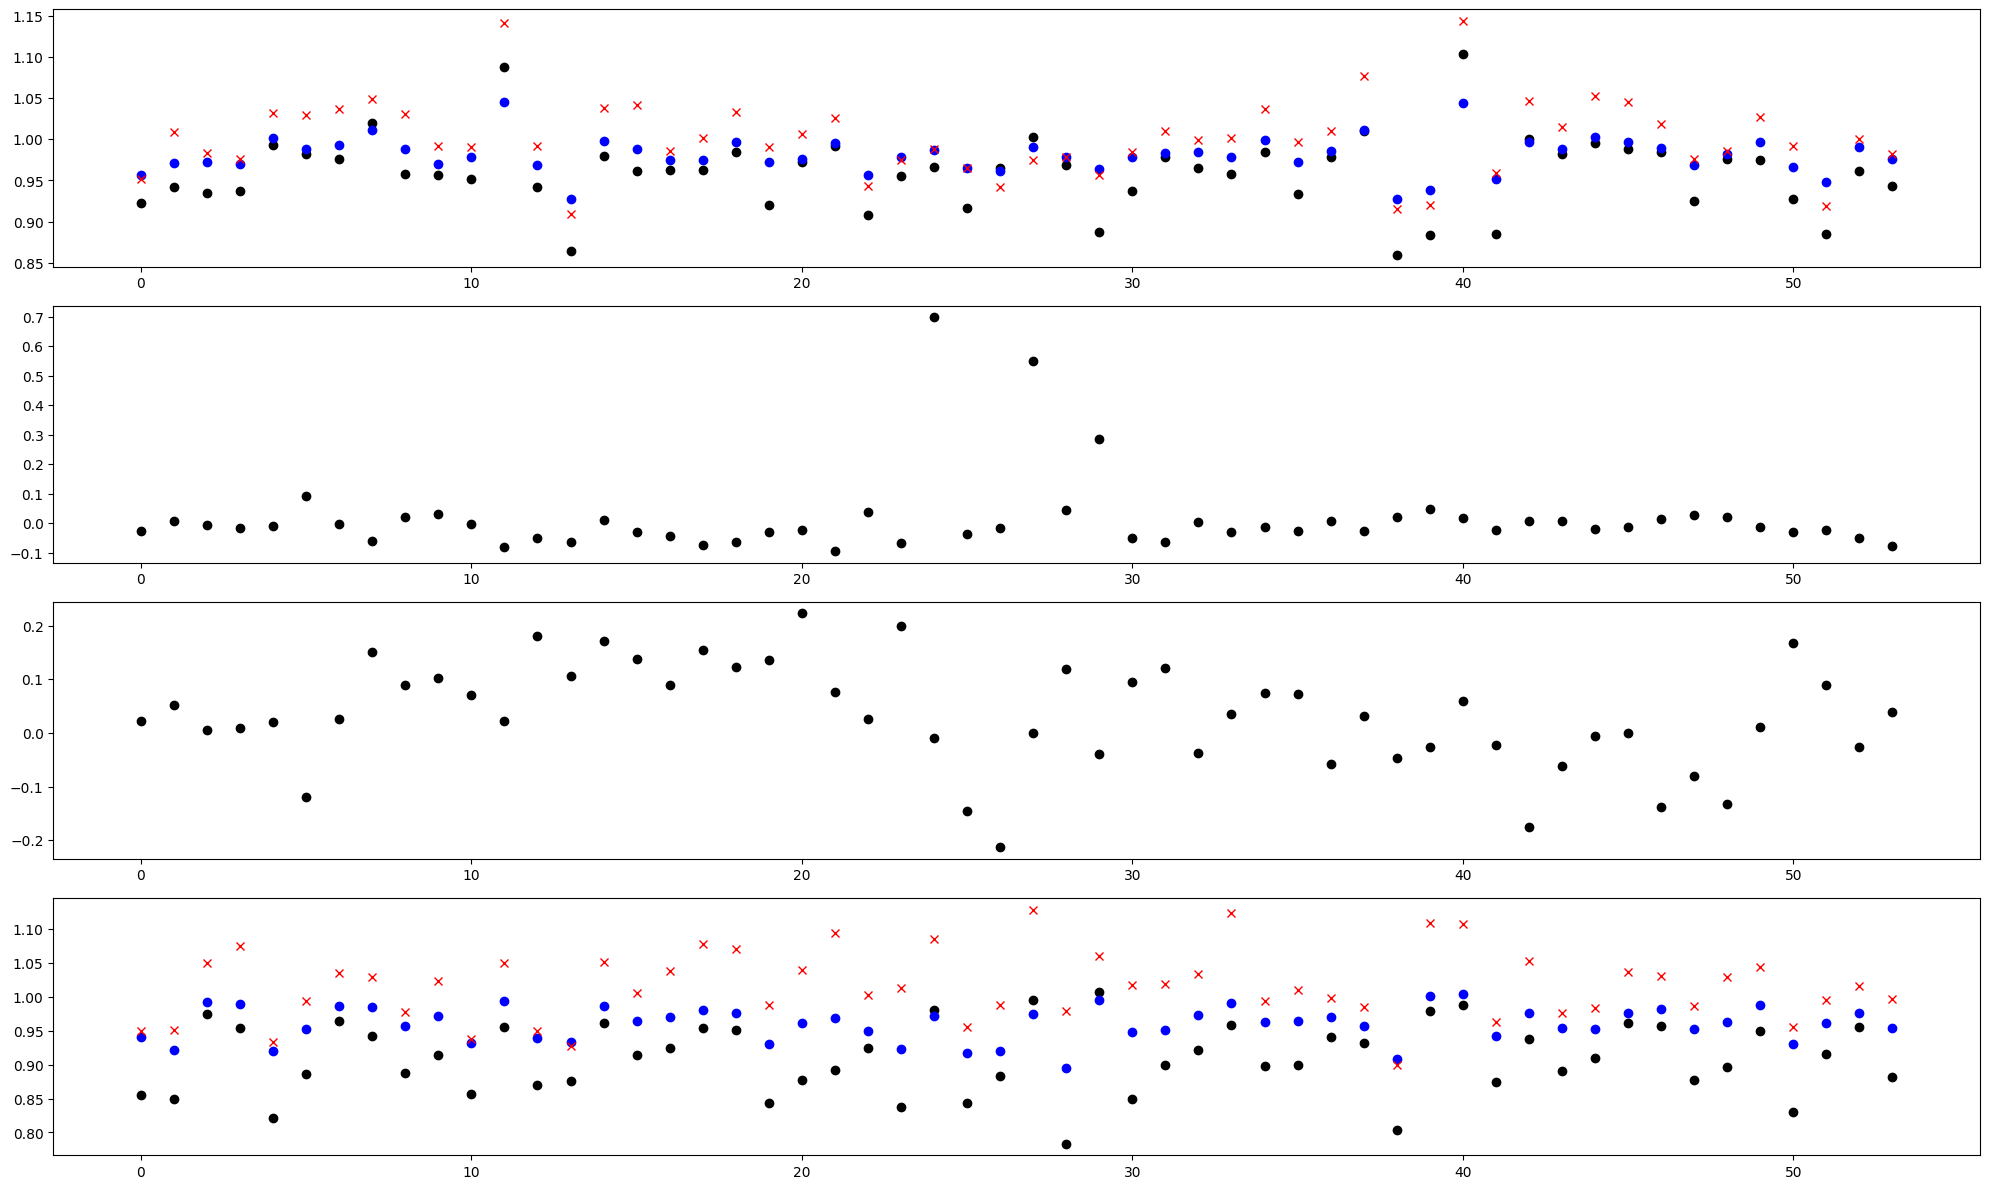

tensor(0.9595, dtype=torch.float64)
tensor(0.0460, dtype=torch.float64)

tensor(0.9084, dtype=torch.float64)
tensor(0.0535, dtype=torch.float64)



In [71]:
# Fit

def jacobian(n11, n33, n13, n14, n31, n32):
    return torch.stack([
        n11, n31, 0*n11, 0*n11,
        0*n11, 0*n11, n13, n33,
        n13, n33, n14**2/n33, 0*n11,
        n14, 0*n11, -n13*n14/n33, 0*n11,
        0*n11, n32**2/n11, n11, n31,
        0*n11, -n31*n32/n11, 0*n11, n32
    ]).reshape(-1, 4)

A = torch.vmap(jacobian)(value_n11, value_n33, value_n13, value_n14, value_n31, value_n32)
B = torch.stack([n11_estimate, n33_estimate, n13_estimate, n14_estimate, n31_estimate, n32_estimate]).T

gxx, gxy, gyx, gyy = torch.linalg.lstsq(A, B).solution.T

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), Gxx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gxx_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), Gxy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), Gyx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), Gyy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gyy_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(gxx.mean())
print(gxx.std())
print()

print(gyy.mean())
print(gyy.std())
print()

## Twiss (BEAM, estimated transport)

In [72]:
# Rescale TbT using estimated gxx and gyy from ratio

# qx->-((gyy qx_bpm-gxy qy_bpm)/(gxy gyx-gxx gyy))
# qy->-((-gyx qx_bpm+gxx qy_bpm)/(gxy gyx-gxx gyy))

twiss.table.x = -((Gyy.reshape(-1, 1)*X.data-Gxy.reshape(-1, 1)*Y.data)/(Gxy*Gyx-Gxx*Gyy).reshape(-1, 1))
twiss.table.y = -((-Gyx.reshape(-1, 1)*X.data+Gxx.reshape(-1, 1)*Y.data)/(Gxy*Gyx-Gxx*Gyy).reshape(-1, 1))

In [73]:
twiss.normal[model.monitor_index] = value_normal
twiss.model.model = 'coupled'

In [74]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 64

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 twiss.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 39.3 s, sys: 1.81 s, total: 41.1 s
Wall time: 2min 39s


In [75]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

In [76]:
# Set all normalization matrix elements

value_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)])

value_n11 = value_normal[:, 0, 0]
value_n12 = value_normal[:, 0, 1]
value_n13 = value_normal[:, 0, 2]
value_n14 = value_normal[:, 0, 3]

value_n21 = value_normal[:, 1, 0]
value_n22 = value_normal[:, 1, 1]
value_n23 = value_normal[:, 1, 2]
value_n24 = value_normal[:, 1, 3]

value_n31 = value_normal[:, 2, 0]
value_n32 = value_normal[:, 2, 1]
value_n33 = value_normal[:, 2, 2]
value_n34 = value_normal[:, 2, 3]

value_n41 = value_normal[:, 3, 0]
value_n42 = value_normal[:, 3, 1]
value_n43 = value_normal[:, 3, 2]
value_n44 = value_normal[:, 3, 3]

## Twiss (BPM, estimated transport)

In [77]:
# TbT is not rescaled, invariants are fixed, tranport matrices are modified

In [78]:
twiss.table.x = X.data
twiss.table.y = Y.data

In [79]:
twiss.normal[model.monitor_index] = bvalue_normal
twiss.model.model = 'coupled'

In [80]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 64

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 twiss.matrix,        # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=ix_out.mean(), # -- ix invariant value
                                 iy=iy_out.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 40.4 s, sys: 1.84 s, total: 42.2 s
Wall time: 2min 31s


In [81]:
# Process twiss

bvalue_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

bvalue_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

bvalue_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

bvalue_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

bvalue_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

bvalue_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

bvalue_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

bvalue_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

bvalue_n11, error_n11 = twiss.process(bvalue_n11, error_n11)
bvalue_n33, error_n33 = twiss.process(bvalue_n33, error_n33)
bvalue_n21, error_n21 = twiss.process(bvalue_n21, error_n21)
bvalue_n43, error_n43 = twiss.process(bvalue_n43, error_n43)
bvalue_n13, error_n13 = twiss.process(bvalue_n13, error_n13)
bvalue_n31, error_n31 = twiss.process(bvalue_n31, error_n31)
bvalue_n14, error_n14 = twiss.process(bvalue_n14, error_n14)
bvalue_n41, error_n41 = twiss.process(bvalue_n41, error_n41)

bvalue = torch.stack([bvalue_n11, bvalue_n33, bvalue_n21, bvalue_n43, bvalue_n13, bvalue_n31, bvalue_n14, bvalue_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(bvalue, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

In [82]:
# Set all normalization matrix elements

bvalue_normal = torch.stack([parametric_normal(w11, w33, w21, w43, w13, w31, w14, w41) for w11, w33, w21, w43, w13, w31, w14, w41 in zip(bvalue_n11, bvalue_n33, bvalue_n21, bvalue_n43, bvalue_n13, bvalue_n31, bvalue_n14, bvalue_n41)])

bvalue_n11 = bvalue_normal[:, 0, 0]
bvalue_n12 = bvalue_normal[:, 0, 1]
bvalue_n13 = bvalue_normal[:, 0, 2]
bvalue_n14 = bvalue_normal[:, 0, 3]

bvalue_n21 = bvalue_normal[:, 1, 0]
bvalue_n22 = bvalue_normal[:, 1, 1]
bvalue_n23 = bvalue_normal[:, 1, 2]
bvalue_n24 = bvalue_normal[:, 1, 3]

bvalue_n31 = bvalue_normal[:, 2, 0]
bvalue_n32 = bvalue_normal[:, 2, 1]
bvalue_n33 = bvalue_normal[:, 2, 2]
bvalue_n34 = bvalue_normal[:, 2, 3]

bvalue_n41 = bvalue_normal[:, 3, 0]
bvalue_n42 = bvalue_normal[:, 3, 1]
bvalue_n43 = bvalue_normal[:, 3, 2]
bvalue_n44 = bvalue_normal[:, 3, 3]

## Fit calibrations

In [83]:
data = []

for i in range(54):

    # print(i)

    nn = torch.stack([value_n11[i],value_n13[i],value_n14[i],value_n21[i],value_n22[i],value_n23[i],value_n24[i],value_n31[i],value_n32[i],value_n33[i],value_n41[i],value_n42[i],value_n43[i],value_n44[i]])
    yn = torch.stack([n11_estimate[i],bvalue_n13[i],n14_estimate[i],bvalue_n21[i],bvalue_n22[i],bvalue_n23[i],bvalue_n24[i],bvalue_n31[i],n32_estimate[i],n33_estimate[i],bvalue_n41[i],bvalue_n42[i],bvalue_n43[i],bvalue_n44[i]])
    
    fn = lambda x: transform(x, *nn)
    
    # xn = torch.stack([g_xx[i], g_xy[i], g_yx[i], g_yy[i]])
    xi = torch.tensor([Gxx[i].item(), Gxy[i].item(), Gyx[i].item(), Gyy[i].item()], dtype=dtype, device=device, requires_grad=True)
    
    optimizer = torch.optim.Adam([xi], lr=0.01)
    loss = torch.nn.MSELoss()
    
    for epoch in range(512):
        
        yi = fn(xi)
        
        error = loss(yi, yn)
        
        optimizer.zero_grad()
        error.backward()
        optimizer.step()
        
    data.append(xi.detach().clone())

Gxx, Gxy, Gyx, Gyy = torch.stack(data).T

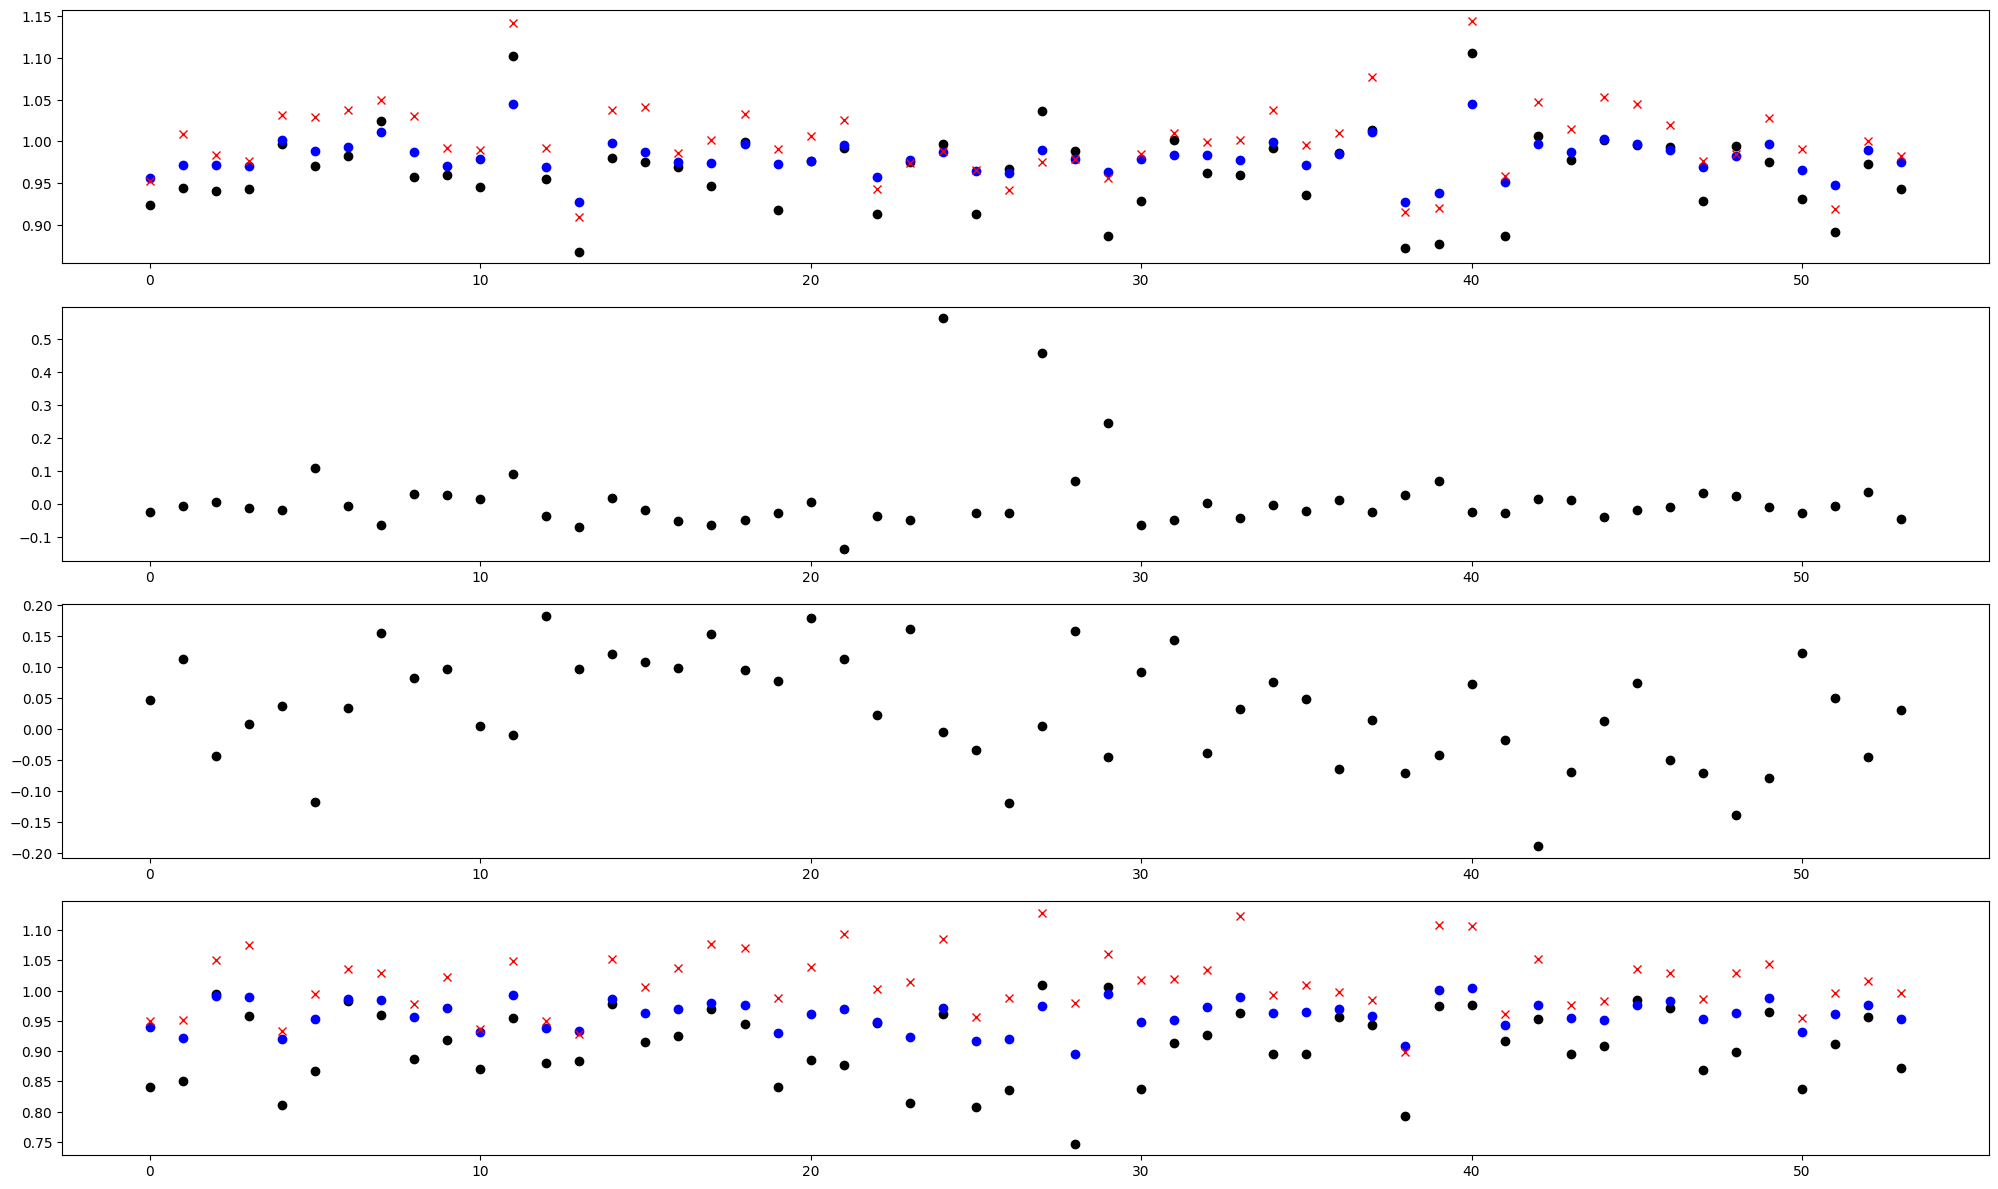

tensor(0.9651, dtype=torch.float64)
tensor(0.0489, dtype=torch.float64)

tensor(0.9113, dtype=torch.float64)
tensor(0.0640, dtype=torch.float64)



In [84]:
# Fit

def jacobian(n11, n33, n13, n14, n31, n32):
    return torch.stack([
        n11, n31, 0*n11, 0*n11,
        0*n11, 0*n11, n13, n33,
        n13, n33, n14**2/n33, 0*n11,
        n14, 0*n11, -n13*n14/n33, 0*n11,
        0*n11, n32**2/n11, n11, n31,
        0*n11, -n31*n32/n11, 0*n11, n32
    ]).reshape(-1, 4)

A = torch.vmap(jacobian)(value_n11, value_n33, value_n13, value_n14, value_n31, value_n32)
B = torch.stack([n11_estimate, n33_estimate, n13_estimate, n14_estimate, n31_estimate, n32_estimate]).T

gxx, gxy, gyx, gyy = torch.linalg.lstsq(A, B).solution.T

plt.figure(figsize=(20, 3*4))
ax = plt.subplot(411)
ax.errorbar(range(model.monitor_count), Gxx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gxx_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gxx_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(412)
ax.errorbar(range(model.monitor_count), Gxy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(413)
ax.errorbar(range(model.monitor_count), Gyx.cpu().numpy(), fmt=' ', marker='o', color='black')
ax = plt.subplot(414)
ax.errorbar(range(model.monitor_count), Gyy.cpu().numpy(), fmt=' ', marker='o', color='black')
ax.errorbar(range(model.monitor_count), gyy_fit.sqrt().cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), gyy_phase.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(gxx.mean())
print(gxx.std())
print()

print(gyy.mean())
print(gyy.std())
print()

## Invariants (refit)

In [85]:
# Note, sample length is increased and more bpms are used for momenta computation
# Estimated matrix is used for transport

In [86]:
twiss.normal[model.monitor_index] = bvalue_normal
twiss.model.model = 'coupled'

In [87]:
twiss.table.x = X.data
twiss.table.y = Y.data

In [88]:
%%time

# Estimate twiss from invariant fit

count = 16

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 512,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 twiss.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=3,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 14.4 s, sys: 697 ms, total: 15.1 s
Wall time: 44 s


In [89]:
# Process fitted invariants

Ix_out = data[:, 0, 0]
Iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(Ix_out, Iy_out, sigma_ix, sigma_iy)

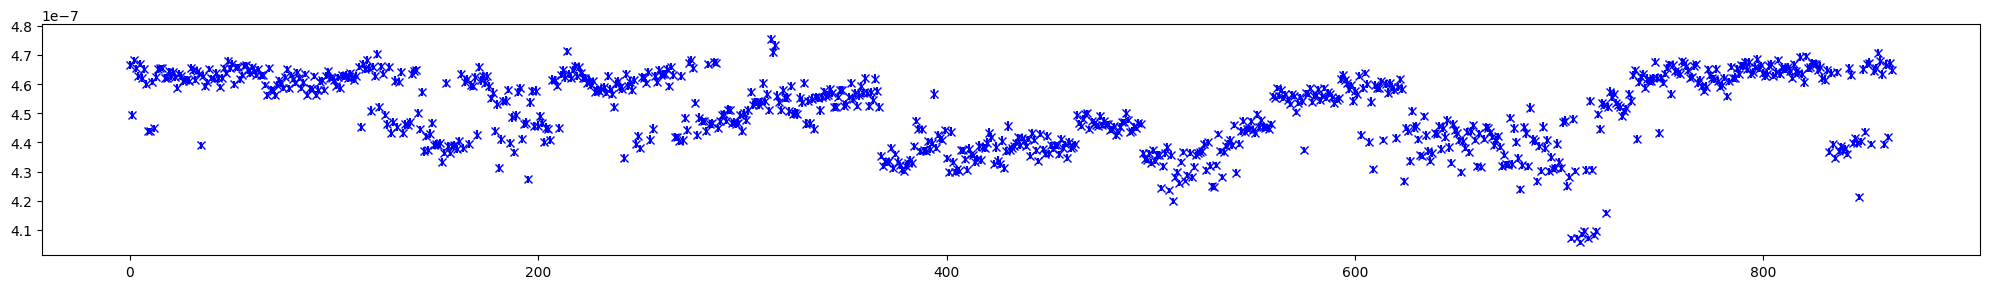

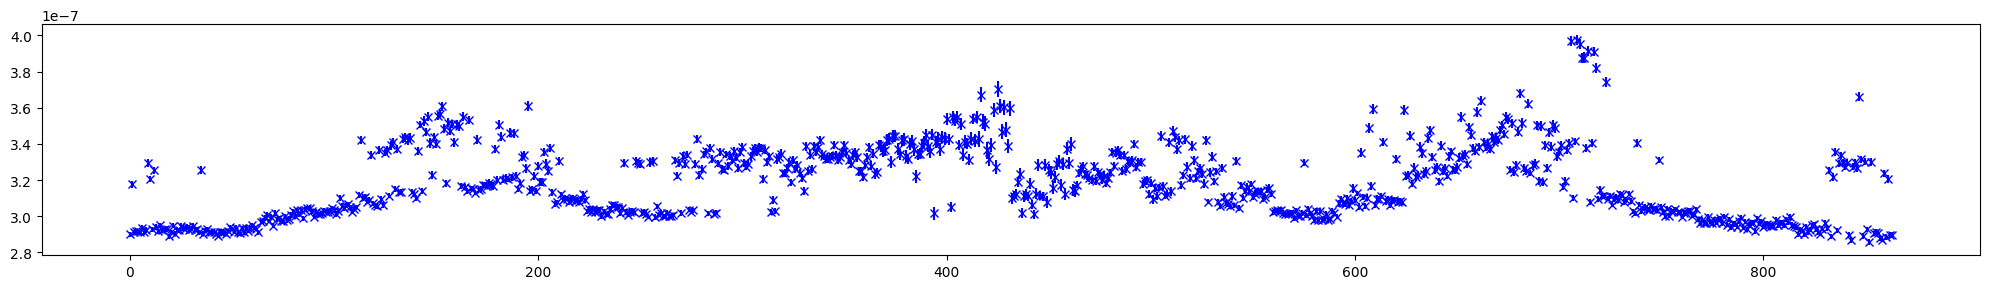

In [90]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), Ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='blue', marker='x', zorder=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), Iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='blue', marker='x', zorder=0)
plt.tight_layout()
plt.show()

In [91]:
# fails at IP